# Pipeline 5: Resident Wellbeing Prediction

## 1. Business Understanding (CRISP-DM Phase 1)

**Business Question:** Can we predict how well a resident will be doing — physically, mentally, and socially — after an extended stay at the safehouse, based on their early-stay trajectory?

**Who cares:** Social workers and program directors. The case explicitly asks: *"which girls are progressing and which are struggling, which interventions are actually working."* This pipeline gives staff an early-warning signal: if a resident's early trajectory suggests poor late-stay wellbeing, staff can intensify support *before* the girl falls through the cracks.

**Three Wellbeing Dimensions (supported by available data):**

| Dimension | Data Source | Proxy Metric |
|---|---|---|
| **Physical** | `health_wellbeing_records` | Mean of health, nutrition, sleep, and energy scores (1–5 scale) |
| **Mental** | `process_recordings` | Session progress rate + positive emotional state rate + (1 – concern rate) |
| **Social** | `home_visitations` + `education_records` | Family cooperation score + favorable visit rate + education progress |

**Composite Wellbeing Index (CWI):** Weighted average of the three dimension scores, scaled 0–10:
- Physical: 40% weight (most directly measurable)
- Mental: 35% weight
- Social: 25% weight

**Temporal Prediction Setup (Longitudinal):**
- Each resident has repeated measurements (health records, sessions, visits) over their stay.
- We split each resident's records at the midpoint: **early period** (first half) vs. **late period** (second half).
- **Features** = aggregated early-period records + resident demographics.
- **Target** = CWI computed from late-period records.
- This is a genuine *out-of-time* prediction: we use what we know early to predict what will happen later.

**Dual Approach:**
1. **Regression (Ridge / Gradient Boosting Regressor):** Predict the continuous CWI (0–10). Output: predicted wellbeing score per resident.
2. **Classification (Logistic / Gradient Boosting Classifier):** Binary `high_wellbeing` = CWI ≥ 6.5. Output: actionable risk flag for case reviews.

**Success Metrics:**
- Regression: RMSE, MAE, R² vs. mean baseline
- Classification: AUC-ROC (cross-validated), confusion matrix, precision-recall

**Ethical note:** With ~60 residents and a very small test set, all findings are directional. The model is a *decision-support tool only* — social worker judgment always overrides the score.


## 2. Data Acquisition & Exploration (CRISP-DM Phase 2)


In [1]:
import sys
sys.path.insert(0, '..')

from pyLibrary import (
    univariate, unistats, bivariate, correlation_heatmap,
    missing_data_diagnostics, missing_data_clean,
    transform_skew, cap_outliers_iqr,
    build_preprocessor, make_pipeline_for_model, split_data,
    eval_regression, eval_classification,
    plot_roc_curve, plot_confusion_matrix, plot_precision_recall,
    cross_validate_model, plot_learning_curve,
    tune_grid, tune_random,
    select_features_rfe, permutation_importance_report,
    feature_importance_plot, plot_logit_coefficients,
    compute_vif, remove_high_vif
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR     = Path('../data/raw')
RANDOM_STATE = 42
print('Imports OK.')

Imports OK.


In [2]:
# ── Load all relevant tables ──────────────────────────────────────────────────
residents   = pd.read_csv(DATA_DIR / 'residents.csv',
                          parse_dates=['date_of_admission', 'date_closed'])
health      = pd.read_csv(DATA_DIR / 'health_wellbeing_records.csv',
                          parse_dates=['record_date'])
recordings  = pd.read_csv(DATA_DIR / 'process_recordings.csv',
                          parse_dates=['session_date'])
education   = pd.read_csv(DATA_DIR / 'education_records.csv',
                          parse_dates=['record_date'])
visitations = pd.read_csv(DATA_DIR / 'home_visitations.csv',
                          parse_dates=['visit_date'])
incidents   = pd.read_csv(DATA_DIR / 'incident_reports.csv',
                          parse_dates=['incident_date'])
plans       = pd.read_csv(DATA_DIR / 'intervention_plans.csv')

for name, tbl in [('residents', residents), ('health', health),
                   ('recordings', recordings), ('education', education),
                   ('visitations', visitations), ('incidents', incidents),
                   ('plans', plans)]:
    print(f'{name:12s}: {tbl.shape}')

residents   : (60, 49)
health      : (534, 14)
recordings  : (2819, 15)
education   : (534, 10)
visitations : (1337, 14)
incidents   : (100, 12)
plans       : (180, 11)


In [3]:
# ── Missing data diagnostics on core tables (Ch. 7) ───────────────────────────
print('=== HEALTH WELLBEING RECORDS ===')
missing_data_diagnostics(health)
print('\n=== PROCESS RECORDINGS ===')
missing_data_diagnostics(recordings)
print('\n=== EDUCATION RECORDS ===')
missing_data_diagnostics(education)
print('\n=== HOME VISITATIONS ===')
missing_data_diagnostics(visitations)

=== HEALTH WELLBEING RECORDS ===
=== Missing data diagnostics ===
Threshold: drop if proportion missing > 0.9
Columns that would be dropped (0): none
Rows that would be dropped: 0
No missing values in any column.
(MAR vs MNAR cannot be distinguished from data; 'MAR/MNAR' means missingness is associated with observed variables.)

=== PROCESS RECORDINGS ===
=== Missing data diagnostics ===
Threshold: drop if proportion missing > 0.9
Columns that would be dropped (1): ['notes_restricted']
Rows that would be dropped: 0

Per-column summary (columns with missing):
  notes_restricted: missing=2819 (100.00%), suggested mechanism=MCAR?
(MAR vs MNAR cannot be distinguished from data; 'MAR/MNAR' means missingness is associated with observed variables.)

=== EDUCATION RECORDS ===
=== Missing data diagnostics ===
Threshold: drop if proportion missing > 0.9
Columns that would be dropped (0): none
Rows that would be dropped: 0
No missing values in any column.
(MAR vs MNAR cannot be distinguished from

{'per_column': {'visitation_id': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'resident_id': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'visit_date': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'social_worker': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'visit_type': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'location_visited': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'family_members_present': {'missing_count': 425,
   'missing_prop': 0.31787584143605085,
   'suggested_mechanism': 'MCAR?'},
  'purpose': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'observations': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'family_cooperation_level': {

In [4]:
# ── Univariate stats on health scores (Ch. 6) ────────────────────────────────
print('=== Health Score Univariate Statistics ===')
unistats(health[['general_health_score', 'nutrition_score',
                  'sleep_quality_score', 'energy_level_score']])

=== Health Score Univariate Statistics ===


,Count,Unique,Type,Min,Max,25%,50%,75%,Mean,Median,Mode,Std,Skew,Kurt
general_health_score,534,121,float64,2.42,4.35,3.04,3.15,3.33,3.20,3.15,3.10,0.26,0.66,1.78
nutrition_score,534,114,float64,2.56,3.95,3.05,3.19,3.35,3.22,3.19,3.10,0.24,0.45,0.13
sleep_quality_score,534,106,float64,2.44,3.97,2.98,3.09,3.24,3.12,3.09,3.02,0.23,0.78,1.69
energy_level_score,534,101,float64,2.35,3.64,2.84,2.96,3.11,2.98,2.96,2.91,0.20,0.31,0.17


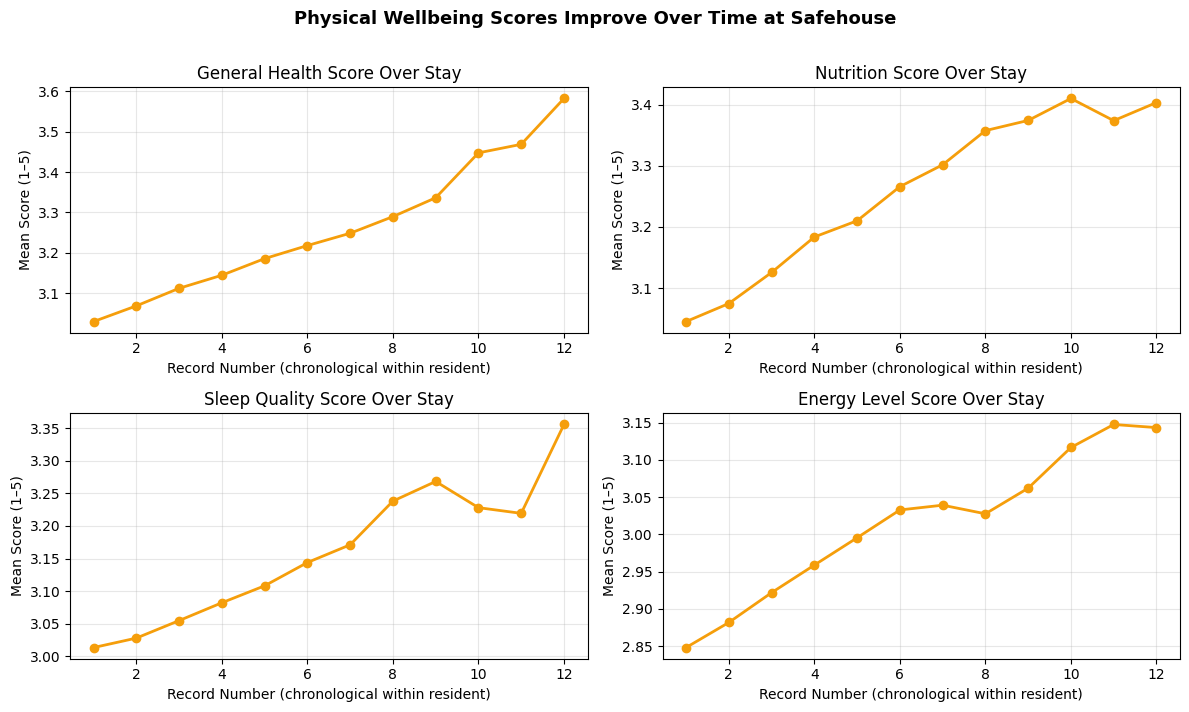


Score improvement (record 1 vs. last record):
  general_health_score: +0.552
  nutrition_score: +0.358
  sleep_quality_score: +0.342
  energy_level_score: +0.295


In [5]:
# ── Visualize health score trends over record number (Ch. 6) ─────────────────
hw_sorted = health.sort_values(['resident_id', 'record_date']).copy()
hw_sorted['record_num'] = hw_sorted.groupby('resident_id').cumcount() + 1

trend = hw_sorted.groupby('record_num')[[
    'general_health_score', 'nutrition_score',
    'sleep_quality_score', 'energy_level_score'
]].mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
score_cols = ['general_health_score', 'nutrition_score',
              'sleep_quality_score', 'energy_level_score']
titles     = ['General Health', 'Nutrition', 'Sleep Quality', 'Energy Level']

for ax, col, title in zip(axes.flatten(), score_cols, titles):
    ax.plot(trend.index, trend[col], marker='o', linewidth=2, color='#f59e0b')
    ax.set_xlabel('Record Number (chronological within resident)')
    ax.set_ylabel('Mean Score (1–5)')
    ax.set_title(f'{title} Score Over Stay')
    ax.grid(alpha=0.3)

plt.suptitle('Physical Wellbeing Scores Improve Over Time at Safehouse',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nScore improvement (record 1 vs. last record):')
for col in score_cols:
    delta = trend[col].iloc[-1] - trend[col].iloc[0]
    print(f'  {col}: +{delta:.3f}')

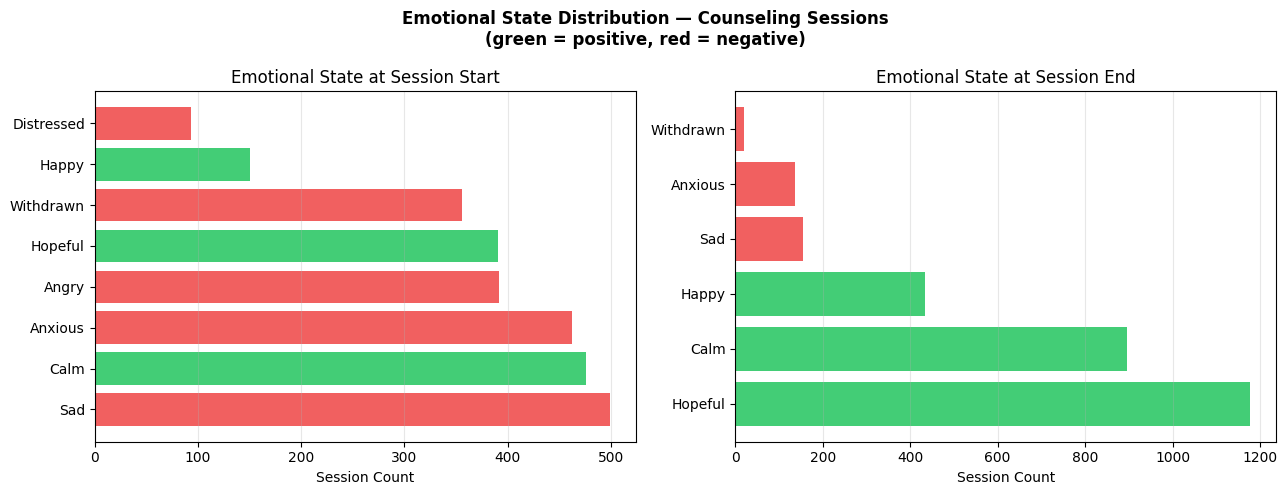

Positive state at session start: 36.1%
Positive state at session end:   89.0%
Session-level improvement:        +52.9%


In [6]:
# ── Visualize emotional state transitions (mental wellbeing, Ch. 8) ──────────
POSITIVE_STATES = {'Happy', 'Hopeful', 'Calm'}

# Valence mapping
state_score = {
    'Happy': 1.0, 'Hopeful': 0.8, 'Calm': 0.6,
    'Anxious': 0.4, 'Sad': 0.3, 'Withdrawn': 0.2,
    'Angry': 0.1, 'Distressed': 0.0
}

recordings['state_end_score'] = recordings['emotional_state_end'].map(state_score)
recordings['state_start_score'] = recordings['emotional_state_observed'].map(state_score)

# Pivot: emotional state at session end by observation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, label in zip(axes,
                            ['emotional_state_observed', 'emotional_state_end'],
                            ['Session Start', 'Session End']):
    counts = recordings[col].value_counts()
    colors = ['#22c55e' if s in POSITIVE_STATES else '#ef4444'
              for s in counts.index]
    ax.barh(counts.index, counts.values, color=colors, alpha=0.85)
    ax.set_xlabel('Session Count')
    ax.set_title(f'Emotional State at {label}')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Emotional State Distribution — Counseling Sessions\n(green = positive, red = negative)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

pct_positive_end = (recordings['emotional_state_end'].isin(POSITIVE_STATES)).mean()
pct_positive_start = (recordings['emotional_state_observed'].isin(POSITIVE_STATES)).mean()
print(f'Positive state at session start: {pct_positive_start:.1%}')
print(f'Positive state at session end:   {pct_positive_end:.1%}')
print(f'Session-level improvement:        +{pct_positive_end - pct_positive_start:.1%}')

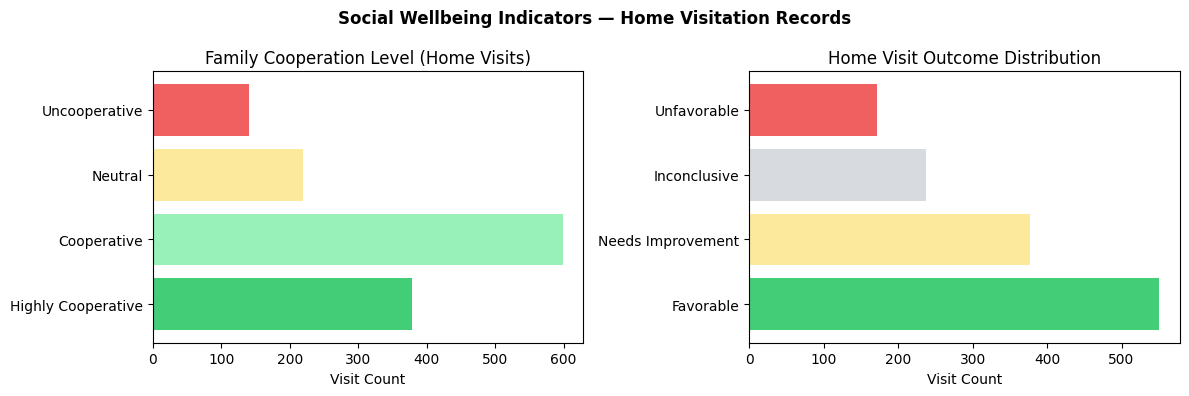

In [7]:
# ── Visualize family cooperation & visit outcomes (social wellbeing, Ch. 8) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

coop_order = ['Highly Cooperative', 'Cooperative', 'Neutral', 'Uncooperative']
coop_counts = visitations['family_cooperation_level'].value_counts().reindex(coop_order)
axes[0].barh(coop_order, coop_counts.values,
             color=['#22c55e', '#86efac', '#fde68a', '#ef4444'], alpha=0.85)
axes[0].set_xlabel('Visit Count')
axes[0].set_title('Family Cooperation Level (Home Visits)')

outcome_order = ['Favorable', 'Needs Improvement', 'Inconclusive', 'Unfavorable']
out_counts = visitations['visit_outcome'].value_counts().reindex(outcome_order)
axes[1].barh(outcome_order, out_counts.values,
             color=['#22c55e', '#fde68a', '#d1d5db', '#ef4444'], alpha=0.85)
axes[1].set_xlabel('Visit Count')
axes[1].set_title('Home Visit Outcome Distribution')

plt.suptitle('Social Wellbeing Indicators — Home Visitation Records',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature Engineering & Target Construction (CRISP-DM Phase 3)

**Core idea — longitudinal split:** For each resident, sort their records chronologically and split at the midpoint.
- **Early period** (first 50% of records): used as **predictor features**
- **Late period** (last 50% of records): used to **compute the target CWI**

This gives us a genuine temporal holdout: we simulate predicting *future* wellbeing from *past* observations.


In [8]:
# ── Helper: split records into early / late for a given table ────────────────
def temporal_split(df, id_col, date_col):
    """Returns (early_df, late_df) by splitting each resident at the midpoint."""
    df = df.sort_values([id_col, date_col]).copy()
    df['_rank']  = df.groupby(id_col).cumcount() + 1
    df['_total'] = df.groupby(id_col)[id_col].transform('count')
    df['_mid']   = (df['_total'] / 2).apply(np.floor).astype(int)
    early = df[df['_rank'] <= df['_mid']].copy()
    late  = df[df['_rank'] >  df['_mid']].copy()
    return early, late

health_early, health_late         = temporal_split(health,      'resident_id', 'record_date')
rec_early,    rec_late            = temporal_split(recordings,  'resident_id', 'session_date')
edu_early,    edu_late            = temporal_split(education,   'resident_id', 'record_date')
vis_early,    vis_late            = temporal_split(visitations, 'resident_id', 'visit_date')

for name, e, l in [('health', health_early, health_late),
                    ('recordings', rec_early, rec_late),
                    ('education', edu_early, edu_late),
                    ('visitations', vis_early, vis_late)]:
    print(f'{name:12s}: early={len(e)} rows  late={len(l)} rows')

health      : early=253 rows  late=281 rows
recordings  : early=1391 rows  late=1428 rows
education   : early=253 rows  late=281 rows
visitations : early=656 rows  late=681 rows


In [9]:
# ── TARGET: Composite Wellbeing Index (CWI) from LATE records ────────────────
#
# Physical Wellbeing Index (PWI) — from late health records
#   health scores are on 1–5 scale → normalize to 0–10

phys_target = health_late.groupby('resident_id').agg(
    pwi_health    = ('general_health_score', 'mean'),
    pwi_nutrition = ('nutrition_score',       'mean'),
    pwi_sleep     = ('sleep_quality_score',   'mean'),
    pwi_energy    = ('energy_level_score',    'mean')
).reset_index()
phys_target['physical_score'] = (
    (phys_target[['pwi_health','pwi_nutrition','pwi_sleep','pwi_energy']].mean(axis=1) - 1)
    / 4 * 10
)  # scale from 1-5 → 0-10

# Mental Wellbeing Index (MWI) — from late counseling sessions
POSITIVE_STATES = {'Happy', 'Hopeful', 'Calm'}
state_score_map  = {'Happy': 1.0, 'Hopeful': 0.8, 'Calm': 0.6,
                    'Anxious': 0.4, 'Sad': 0.3, 'Withdrawn': 0.2,
                    'Angry': 0.1, 'Distressed': 0.0}

rec_late = rec_late.copy()
rec_late['end_score'] = rec_late['emotional_state_end'].map(state_score_map)
rec_late['progress_bool']  = rec_late['progress_noted'].astype(str).str.lower().eq('true')
rec_late['concern_bool']   = rec_late['concerns_flagged'].astype(str).str.lower().eq('true')

mental_target = rec_late.groupby('resident_id').agg(
    late_pos_state_rate  = ('end_score',        'mean'),
    late_progress_rate   = ('progress_bool',    'mean'),
    late_concern_rate    = ('concern_bool',      'mean')
).reset_index()
# MWI components all 0-1 → average → scale to 0-10
mental_target['mental_score'] = (
    (mental_target['late_pos_state_rate'] +
     mental_target['late_progress_rate']  +
     (1 - mental_target['late_concern_rate'])) / 3 * 10
)

# Social Wellbeing Index (SWI) — from late visitations + education
coop_map    = {'Highly Cooperative': 1.0, 'Cooperative': 0.75,
               'Neutral': 0.5, 'Uncooperative': 0.25}
outcome_map = {'Favorable': 1.0, 'Needs Improvement': 0.5,
               'Inconclusive': 0.25, 'Unfavorable': 0.0}

vis_late = vis_late.copy()
vis_late['coop_score']    = vis_late['family_cooperation_level'].map(coop_map)
vis_late['outcome_score'] = vis_late['visit_outcome'].map(outcome_map)

social_vis = vis_late.groupby('resident_id').agg(
    late_coop_score    = ('coop_score',    'mean'),
    late_outcome_score = ('outcome_score', 'mean')
).reset_index()

social_edu = edu_late.groupby('resident_id').agg(
    late_edu_progress = ('progress_percent', 'mean')  # already 0-100
).reset_index()

social_target = social_vis.merge(social_edu, on='resident_id', how='outer')
social_target['late_edu_progress'] = social_target['late_edu_progress'].fillna(0)
# SWI components: coop (0-1), outcome (0-1), edu_progress/100 → average → scale 0-10
social_target['social_score'] = (
    (social_target['late_coop_score']    +
     social_target['late_outcome_score'] +
     social_target['late_edu_progress'] / 100)
    / 3 * 10
)

# Merge all three target components
targets = phys_target[['resident_id', 'physical_score']]\
    .merge(mental_target[['resident_id', 'mental_score']], on='resident_id', how='outer')\
    .merge(social_target[['resident_id', 'social_score']], on='resident_id', how='outer')

# CWI = weighted composite (physical 40%, mental 35%, social 25%)
targets['cwi'] = (
    0.40 * targets['physical_score'].fillna(targets['physical_score'].mean()) +
    0.35 * targets['mental_score'].fillna(targets['mental_score'].mean()) +
    0.25 * targets['social_score'].fillna(targets['social_score'].mean())
)
targets['high_wellbeing'] = (targets['cwi'] >= 6.5).astype(int)  # classification target

print('Target distribution:')
print(targets[['physical_score','mental_score','social_score','cwi']].describe().round(2))
print(f'\nhigh_wellbeing rate: {targets["high_wellbeing"].mean():.1%}')

Target distribution:
       physical_score  mental_score  social_score    cwi
count           60.00         60.00         58.00  60.00
mean             5.48          8.02          7.68   6.92
std              0.40          0.43          0.70   0.29
min              4.16          6.69          5.35   5.98
25%              5.22          7.72          7.22   6.74
50%              5.45          8.08          7.78   6.96
75%              5.75          8.36          8.15   7.08
max              6.41          8.77          9.01   7.43

high_wellbeing rate: 93.3%


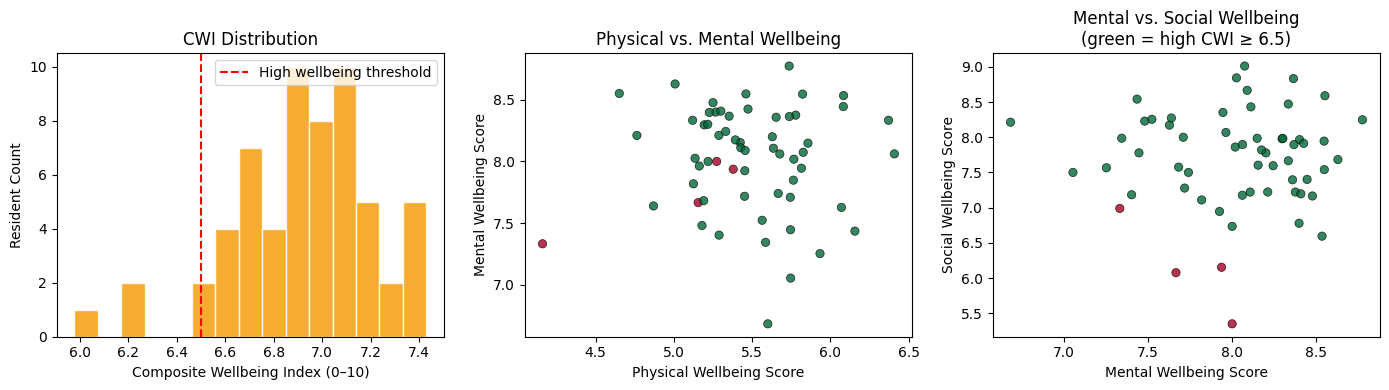

In [10]:
# ── Visualize CWI distribution & dimension correlation ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# CWI histogram
axes[0].hist(targets['cwi'].dropna(), bins=15, color='#f59e0b', edgecolor='white', alpha=0.85)
axes[0].axvline(6.5, color='red', linestyle='--', label='High wellbeing threshold')
axes[0].set_xlabel('Composite Wellbeing Index (0–10)')
axes[0].set_ylabel('Resident Count')
axes[0].set_title('CWI Distribution')
axes[0].legend()

# Dimension scatter
axes[1].scatter(targets['physical_score'], targets['mental_score'],
                c=targets['high_wellbeing'], cmap='RdYlGn', alpha=0.8, edgecolors='k', linewidth=0.5)
axes[1].set_xlabel('Physical Wellbeing Score')
axes[1].set_ylabel('Mental Wellbeing Score')
axes[1].set_title('Physical vs. Mental Wellbeing')

axes[2].scatter(targets['mental_score'], targets['social_score'],
                c=targets['high_wellbeing'], cmap='RdYlGn', alpha=0.8, edgecolors='k', linewidth=0.5)
axes[2].set_xlabel('Mental Wellbeing Score')
axes[2].set_ylabel('Social Wellbeing Score')
axes[2].set_title('Mental vs. Social Wellbeing\n(green = high CWI ≥ 6.5)')

plt.tight_layout()
plt.show()

In [11]:
# ── FEATURES: Aggregate EARLY-period records ──────────────────────────────────

# --- Physical baseline (early health records) ---
phys_feats = health_early.groupby('resident_id').agg(
    early_health    = ('general_health_score', 'mean'),
    early_nutrition = ('nutrition_score',       'mean'),
    early_sleep     = ('sleep_quality_score',   'mean'),
    early_energy    = ('energy_level_score',    'mean'),
    health_record_count = ('record_date',       'count'),
    phys_checkup_rate   = ('psychological_checkup_done',
                            lambda x: x.astype(str).str.lower().eq('true').mean())
).reset_index()

# --- Mental baseline (early counseling sessions) ---
rec_early = rec_early.copy()
rec_early['end_score']     = rec_early['emotional_state_end'].map(state_score_map)
rec_early['progress_bool'] = rec_early['progress_noted'].astype(str).str.lower().eq('true')
rec_early['concern_bool']  = rec_early['concerns_flagged'].astype(str).str.lower().eq('true')

mental_feats = rec_early.groupby('resident_id').agg(
    early_pos_state_rate = ('end_score',        'mean'),
    early_progress_rate  = ('progress_bool',    'mean'),
    early_concern_rate   = ('concern_bool',      'mean'),
    early_session_count  = ('recording_id',     'count'),
    early_avg_duration   = ('session_duration_minutes', 'mean')
).reset_index()

# --- Social baseline (early visitations + education) ---
vis_early = vis_early.copy()
vis_early['coop_score']    = vis_early['family_cooperation_level'].map(coop_map)
vis_early['outcome_score'] = vis_early['visit_outcome'].map(outcome_map)

social_feats_vis = vis_early.groupby('resident_id').agg(
    early_coop_score    = ('coop_score',    'mean'),
    early_outcome_score = ('outcome_score', 'mean'),
    early_safety_concern_rate = ('safety_concerns_noted',
                                  lambda x: x.astype(str).str.lower().eq('true').mean()),
    early_visit_count   = ('visitation_id', 'count')
).reset_index()

social_feats_edu = edu_early.groupby('resident_id').agg(
    early_edu_progress  = ('progress_percent', 'mean'),
    early_attendance    = ('attendance_rate',   'mean'),
    early_edu_completed = ('completion_status', lambda x: (x == 'Completed').mean())
).reset_index()

# --- Adverse events (incidents span full stay, weight by length of stay) ---
inc_feats = incidents.groupby('resident_id').agg(
    incident_count     = ('incident_id', 'count'),
    high_sev_count     = ('severity',    lambda x: (x == 'High').sum())
).reset_index()

# --- Intervention plan engagement ---
plan_feats = plans.groupby('resident_id').agg(
    plan_count           = ('plan_id',  'count'),
    early_plan_comp_rate = ('status',   lambda x: (x == 'Completed').mean())
).reset_index()

print('Feature aggregations complete.')

Feature aggregations complete.


In [12]:
# ── Resident demographics & risk features ──────────────────────────────────────
res_feats = residents.copy()

risk_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
res_feats['initial_risk_enc'] = res_feats['initial_risk_level'].map(risk_map)

# Number of adverse sub-categories (trauma load)
sub_cat_cols = [c for c in res_feats.columns if c.startswith('sub_cat_')]
res_feats['trauma_load'] = res_feats[sub_cat_cols].apply(
    lambda row: sum(str(v).lower() == 'true' for v in row), axis=1
)

# Age at admission (parsed from age_upon_admission string)
res_feats['age_admission'] = (
    res_feats['age_upon_admission']
    .str.extract(r'(\d+)\s*Years')[0].astype(float)
)

# Family vulnerability flags
fam_cols = ['family_is_4ps', 'family_solo_parent', 'family_indigenous',
             'family_parent_pwd', 'family_informal_settler', 'is_pwd']
res_feats['family_vulnerability'] = res_feats[fam_cols].apply(
    lambda row: sum(str(v).lower() == 'true' for v in row), axis=1
)

res_cols_keep = [
    'resident_id', 'safehouse_id', 'case_category',
    'initial_risk_enc', 'trauma_load', 'age_admission', 'family_vulnerability'
]
res_feats = res_feats[res_cols_keep]

print('Resident feature shape:', res_feats.shape)

Resident feature shape: (60, 7)


In [13]:
# ── Merge all features + targets ─────────────────────────────────────────────
df = res_feats.copy()
for feat_df in [phys_feats, mental_feats, social_feats_vis,
                social_feats_edu, inc_feats, plan_feats]:
    df = df.merge(feat_df, on='resident_id', how='left')

df = df.merge(targets[['resident_id', 'cwi', 'high_wellbeing',
                         'physical_score', 'mental_score', 'social_score']],
              on='resident_id', how='inner')

# Fill NaN aggregates (residents with no records in a table) with 0
fill_zero_cols = [
    'early_health', 'early_nutrition', 'early_sleep', 'early_energy',
    'health_record_count', 'phys_checkup_rate',
    'early_pos_state_rate', 'early_progress_rate', 'early_concern_rate',
    'early_session_count', 'early_avg_duration',
    'early_coop_score', 'early_outcome_score',
    'early_safety_concern_rate', 'early_visit_count',
    'early_edu_progress', 'early_attendance', 'early_edu_completed',
    'incident_count', 'high_sev_count', 'plan_count', 'early_plan_comp_rate'
]
for col in fill_zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print(f'Modeling dataset: {len(df)} residents with targets')
print(f'Columns: {df.shape[1]}')
print(f'high_wellbeing rate: {df["high_wellbeing"].mean():.1%}')
print(f'CWI range: {df["cwi"].min():.2f} – {df["cwi"].max():.2f}')

Modeling dataset: 60 residents with targets
Columns: 34
high_wellbeing rate: 93.3%
CWI range: 5.98 – 7.43


## 4. Exploratory Data Analysis on Modeling Dataset (CRISP-DM Phase 2, continued)


In [14]:
# ── Univariate statistics on features (Ch. 6) ─────────────────────────────────
FEATURE_COLS = [
    'initial_risk_enc', 'trauma_load', 'age_admission', 'family_vulnerability',
    'early_health', 'early_nutrition', 'early_sleep', 'early_energy',
    'health_record_count', 'phys_checkup_rate',
    'early_pos_state_rate', 'early_progress_rate', 'early_concern_rate',
    'early_session_count', 'early_avg_duration',
    'early_coop_score', 'early_outcome_score',
    'early_safety_concern_rate', 'early_visit_count',
    'early_edu_progress', 'early_attendance', 'early_edu_completed',
    'incident_count', 'high_sev_count',
    'plan_count', 'early_plan_comp_rate',
    'case_category'
]

feat_df = df[FEATURE_COLS + ['cwi', 'high_wellbeing']].copy()

print('=== Feature Univariate Statistics ===')
unistats(feat_df.select_dtypes(include='number'))

=== Feature Univariate Statistics ===


,Count,Unique,Type,Min,Max,25%,50%,75%,Mean,Median,Mode,Std,Skew,Kurt
initial_risk_enc,60,4,int64,0.00,3.00,1.00,1.00,2.00,1.22,1.00,1.00,0.90,0.26,-0.69
trauma_load,60,6,int64,0.00,5.00,1.00,2.00,2.00,1.60,2.00,2.00,1.17,0.58,0.23
age_admission,60,4,float64,9.00,18.00,12.00,15.00,15.00,14.05,15.00,15.00,2.95,-0.31,-0.85
family_vulnerability,60,5,int64,0.00,4.00,0.75,1.00,2.00,1.13,1.00,1.00,0.93,0.78,0.56
early_health,60,60,float64,2.59,3.41,3.03,3.10,3.20,3.10,3.10,2.59,0.16,-0.68,1.40
early_nutrition,60,59,float64,2.62,3.41,3.03,3.12,3.21,3.11,3.12,3.21,0.14,-0.56,1.30
early_sleep,60,57,float64,2.55,3.44,2.96,3.05,3.13,3.05,3.05,3.11,0.15,-0.05,1.62
early_energy,60,56,float64,2.54,3.17,2.82,2.90,2.97,2.91,2.90,2.90,0.13,-0.10,0.54
health_record_count,60,4,int64,3.00,6.00,3.00,4.00,5.00,4.22,4.00,4.00,1.03,0.42,-0.91
phys_checkup_rate,60,12,float64,0.00,1.00,0.33,0.50,0.67,0.48,0.50,0.33,0.23,-0.14,-0.06


=== Bivariate vs. Composite Wellbeing Index ===


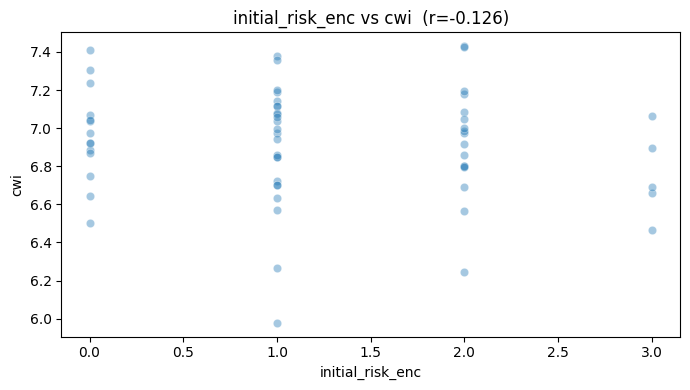

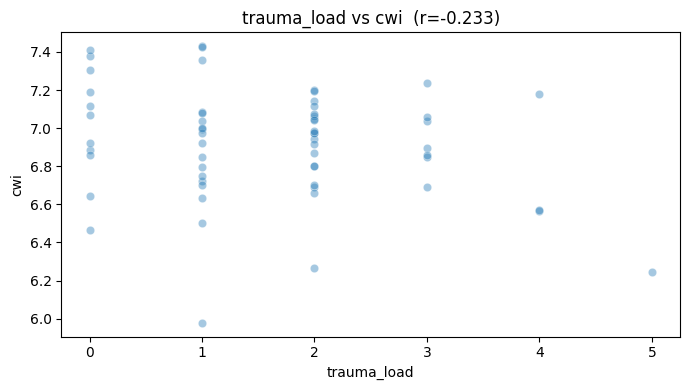

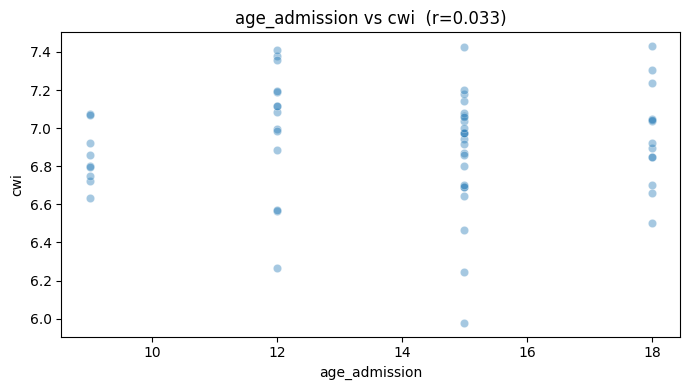

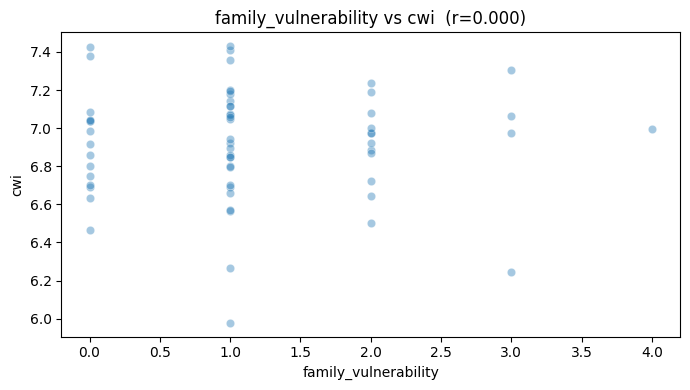

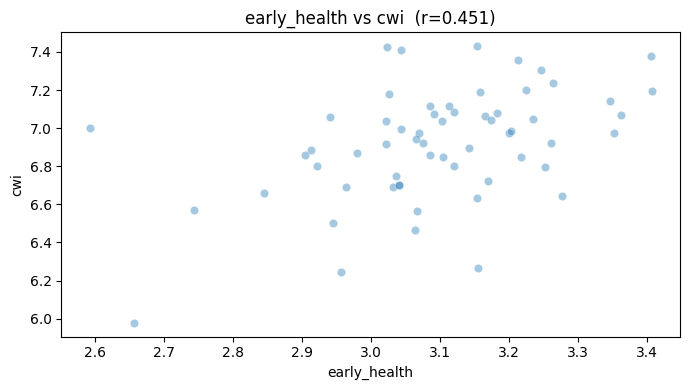

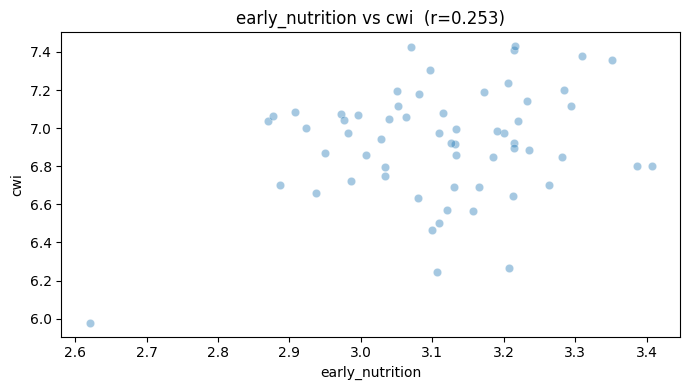

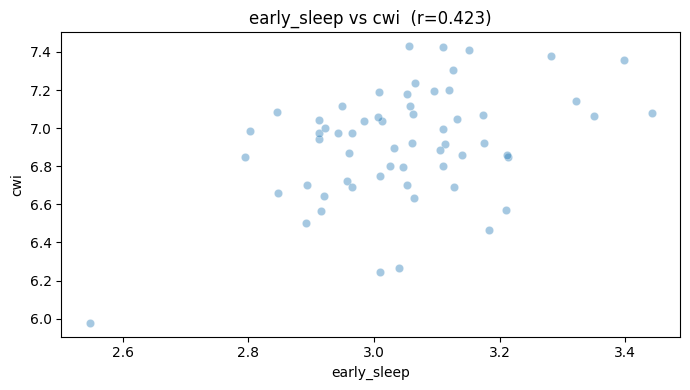

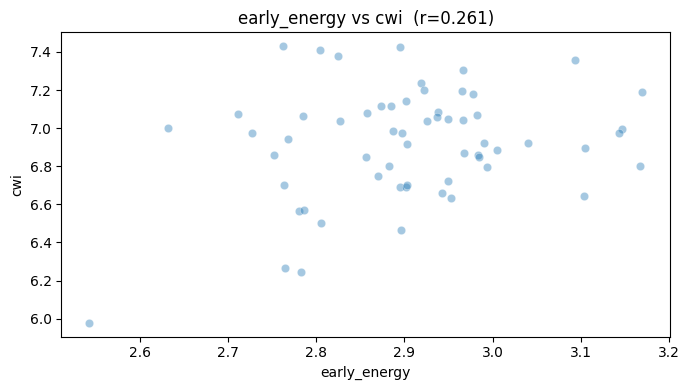

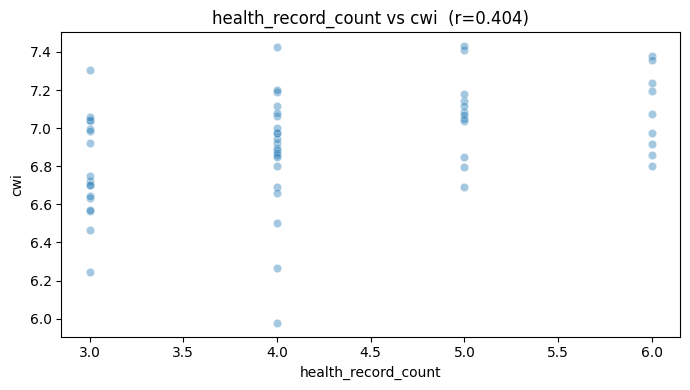

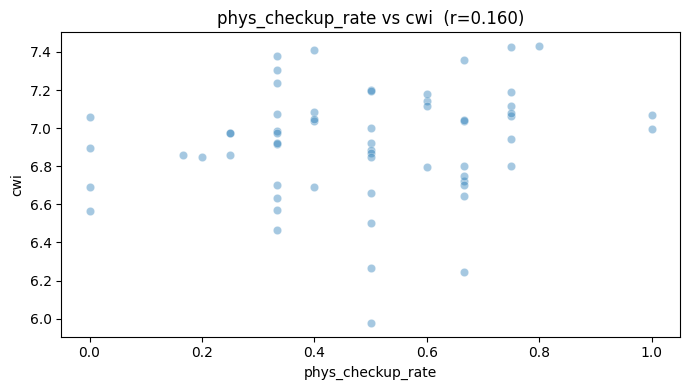

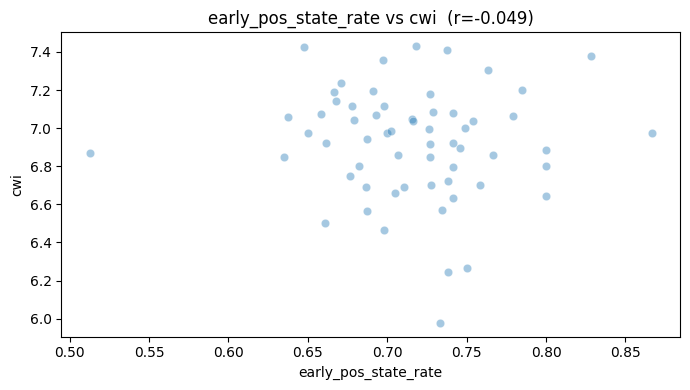

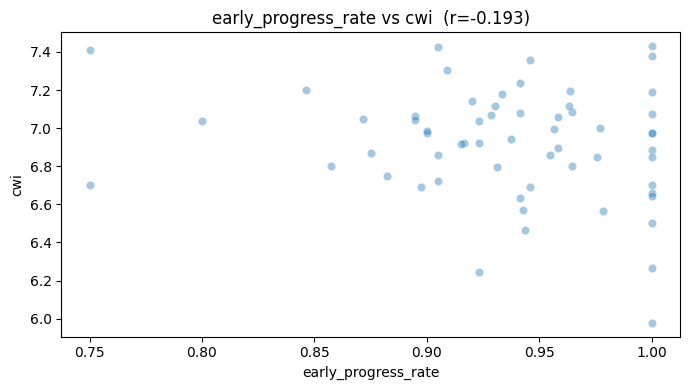

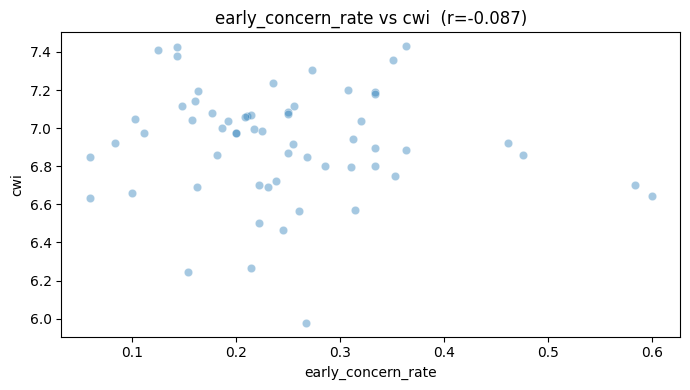

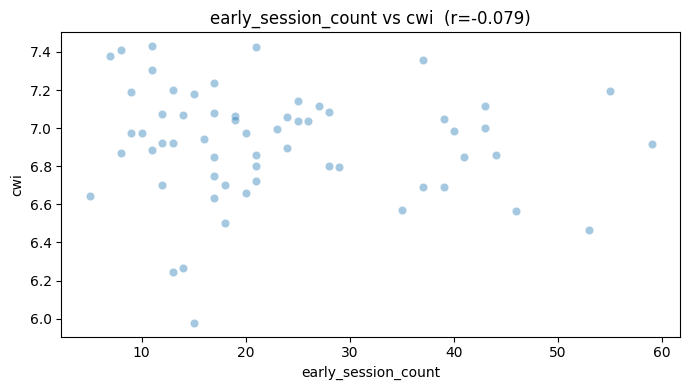

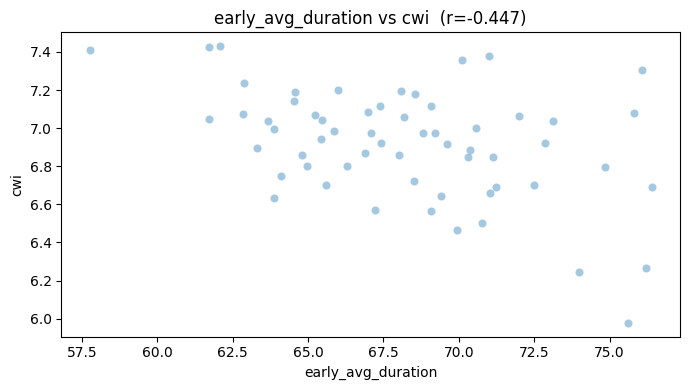

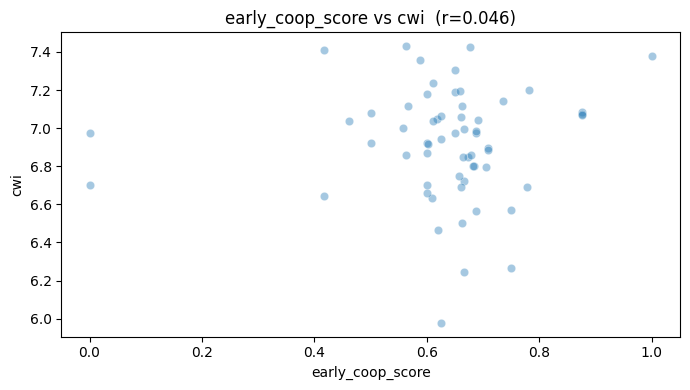

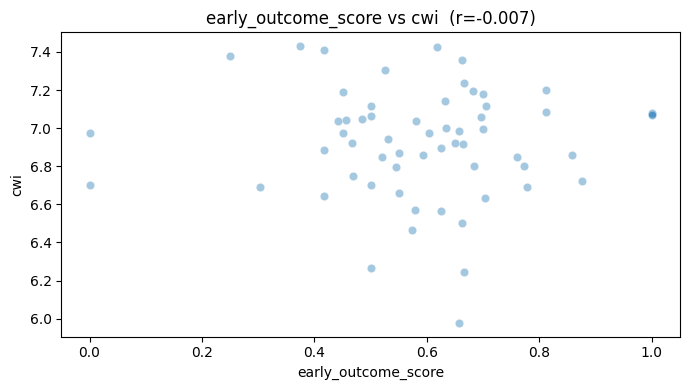

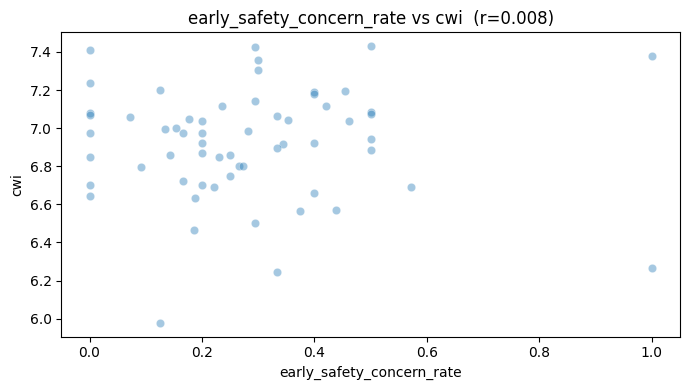

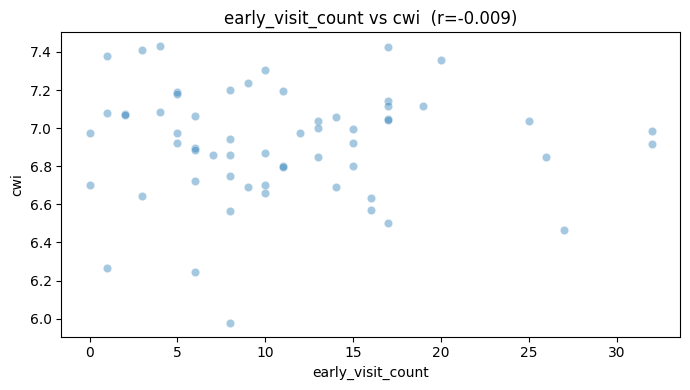

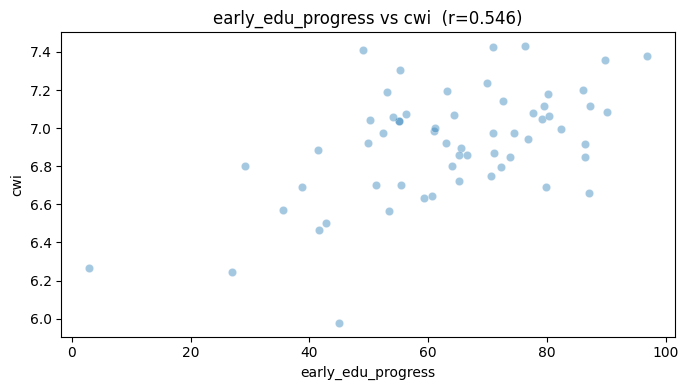

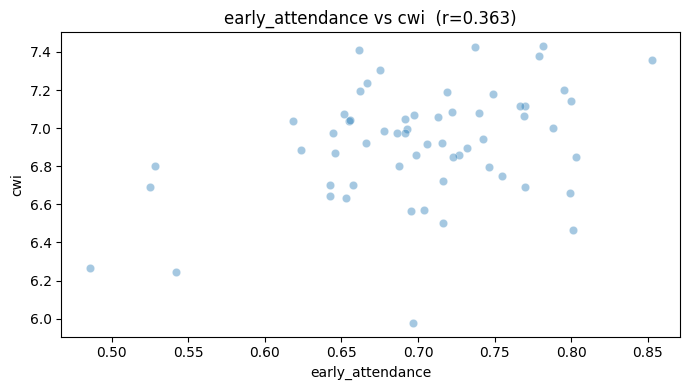

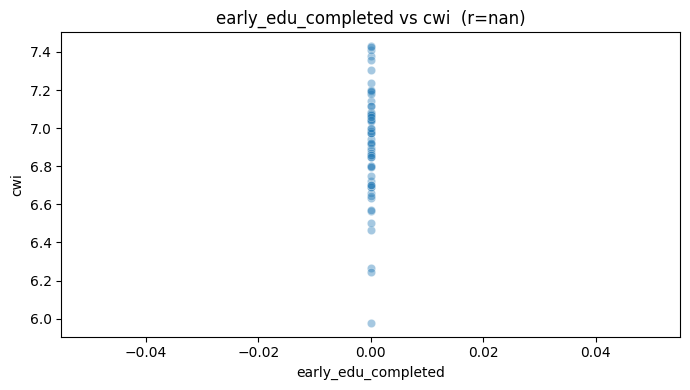

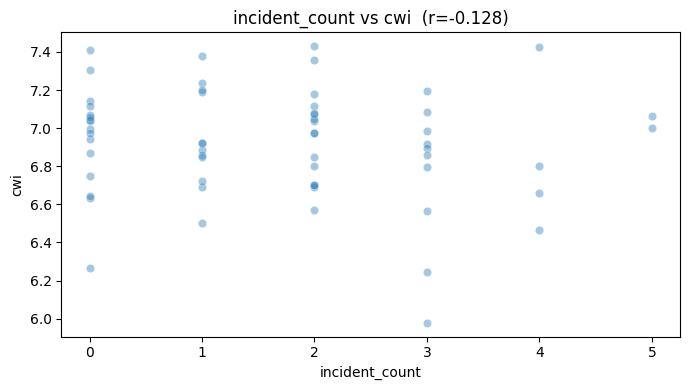

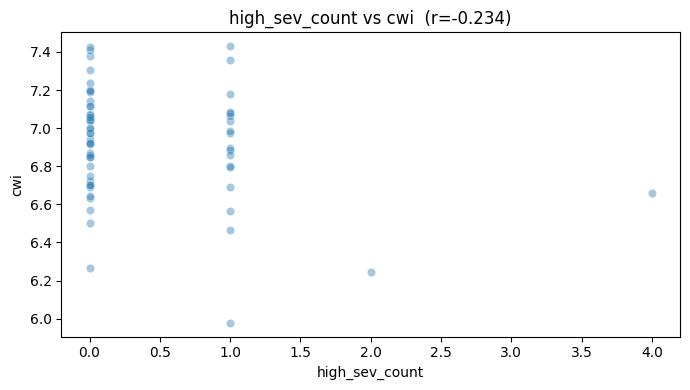

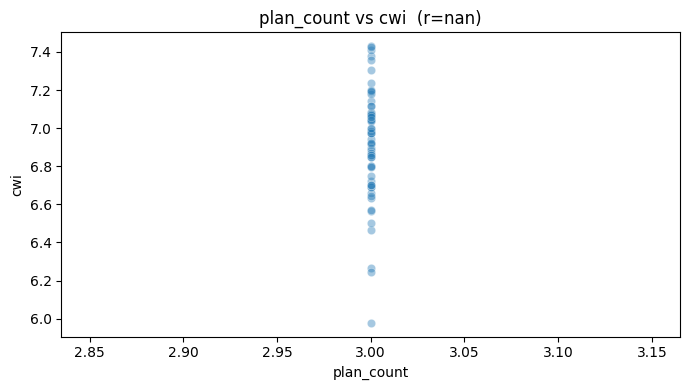

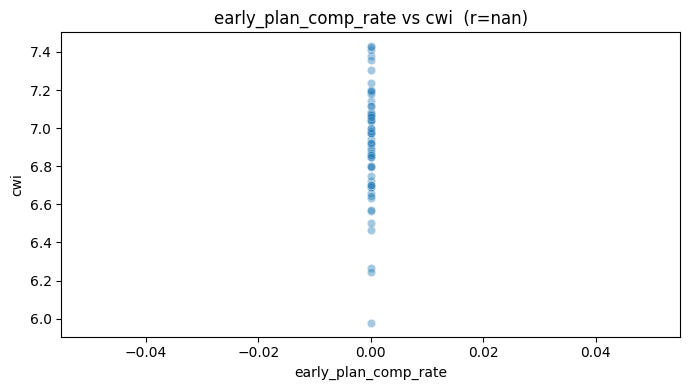

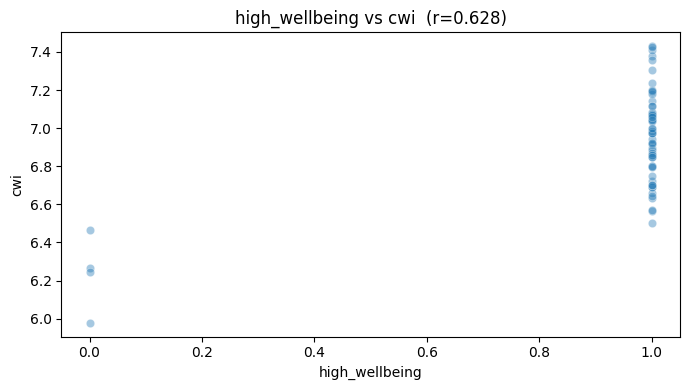

                      Feature  Pearson_r
0              high_wellbeing     0.6284
1          early_edu_progress     0.5459
2                early_health     0.4511
3          early_avg_duration    -0.4467
4                 early_sleep     0.4225
5         health_record_count     0.4044
6            early_attendance     0.3626
7                early_energy     0.2614
8             early_nutrition     0.2526
9              high_sev_count    -0.2340
10                trauma_load    -0.2326
11        early_progress_rate    -0.1926
12          phys_checkup_rate     0.1599
13             incident_count    -0.1280
14           initial_risk_enc    -0.1259
15         early_concern_rate    -0.0873
16        early_session_count    -0.0788
17       early_pos_state_rate    -0.0490
18           early_coop_score     0.0461
19              age_admission     0.0334
20          early_visit_count    -0.0091
21  early_safety_concern_rate     0.0076
22        early_outcome_score    -0.0072
23       family_

In [15]:
# ── Bivariate: each feature vs. CWI target (Ch. 8) ───────────────────────────
print('=== Bivariate vs. Composite Wellbeing Index ===')
corr_results = bivariate(feat_df.select_dtypes(include='number'), target='cwi')
print(corr_results)

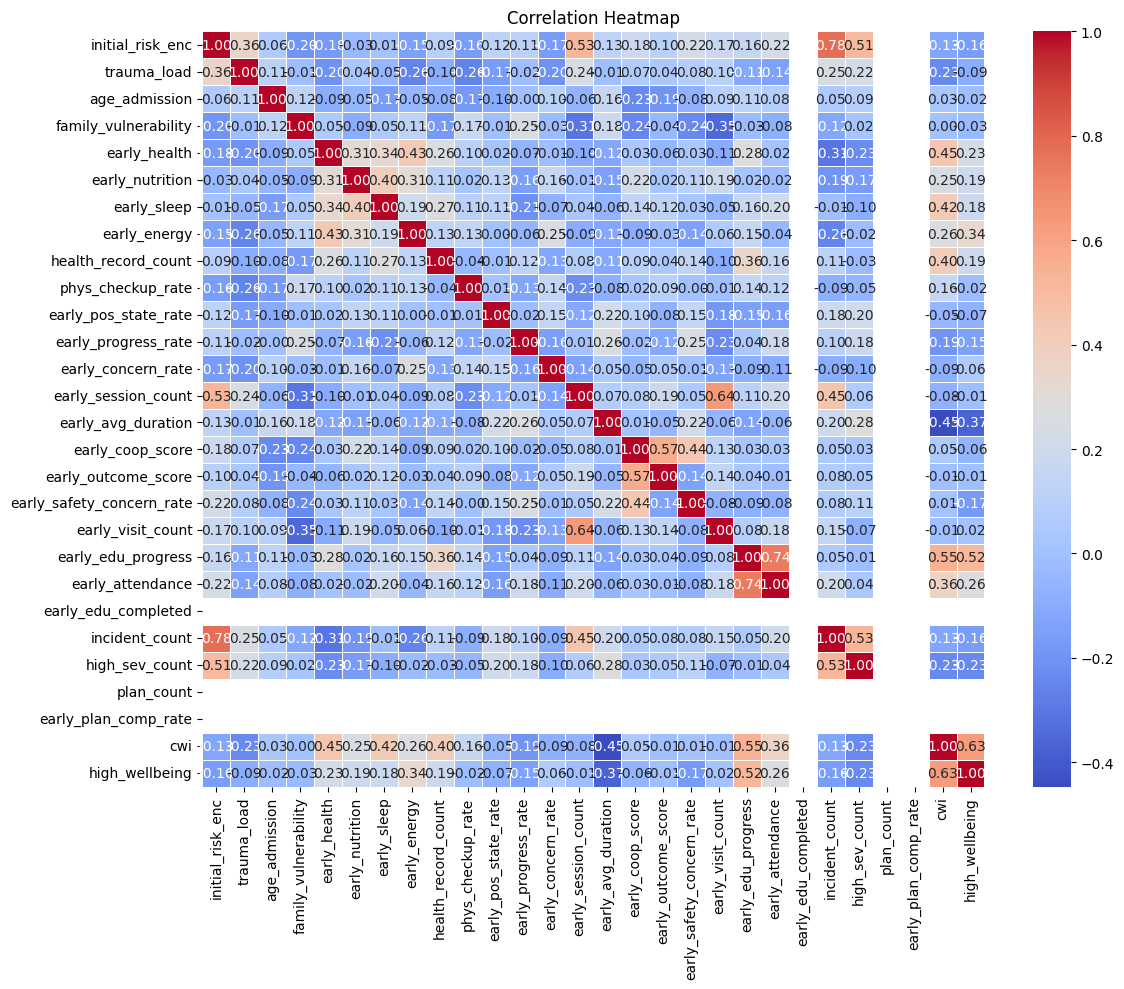

,initial_risk_enc,trauma_load,age_admission,family_vulnerability,early_health,early_nutrition,early_sleep,early_energy,health_record_count,phys_checkup_rate,...,early_visit_count,early_edu_progress,early_attendance,early_edu_completed,incident_count,high_sev_count,plan_count,early_plan_comp_rate,cwi,high_wellbeing
initial_risk_enc,1.000000,0.356678,0.059480,-0.196477,-0.175354,-0.034620,0.010638,-0.149074,0.094694,-0.158651,...,0.171932,0.161359,0.223276,NaN,0.775854,0.508218,NaN,NaN,-0.125888,-0.159060
trauma_load,0.356678,1.000000,0.109328,-0.012501,-0.201450,0.037035,-0.048840,-0.256105,-0.096171,-0.255883,...,0.099341,-0.114799,-0.143639,NaN,0.251423,0.221829,NaN,NaN,-0.232586,-0.092351
age_admission,0.059480,0.109328,1.000000,0.121272,-0.094876,-0.052441,-0.169658,-0.046252,-0.082036,-0.170901,...,0.093513,0.114065,0.081319,NaN,0.045627,0.089489,NaN,NaN,0.033439,-0.018283
family_vulnerability,-0.196477,-0.012501,0.121272,1.000000,0.051786,-0.093403,0.052822,0.113693,-0.172951,0.173752,...,-0.350802,-0.026874,-0.080848,NaN,-0.122845,0.021034,NaN,NaN,0.000361,-0.033842
early_health,-0.175354,-0.201450,-0.094876,0.051786,1.000000,0.312868,0.337440,0.431881,0.256769,0.103060,...,-0.106044,0.280703,0.015157,NaN,-0.310293,-0.231760,NaN,NaN,0.451093,0.231169
early_nutrition,-0.034620,0.037035,-0.052441,-0.093403,0.312868,1.000000,0.403691,0.306613,0.108185,0.017919,...,0.189294,0.020105,-0.022796,NaN,-0.194123,-0.167065,NaN,NaN,0.252592,0.194478
early_sleep,0.010638,-0.048840,-0.169658,0.052822,0.337440,0.403691,1.000000,0.193348,0.268220,0.105500,...,-0.049737,0.164155,0.203364,NaN,-0.007310,-0.096115,NaN,NaN,0.422550,0.182917
early_energy,-0.149074,-0.256105,-0.046252,0.113693,0.431881,0.306613,0.193348,1.000000,0.125611,0.134620,...,0.061143,0.154446,-0.042928,NaN,-0.255012,-0.024830,NaN,NaN,0.261427,0.338436
health_record_count,0.094694,-0.096171,-0.082036,-0.172951,0.256769,0.108185,0.268220,0.125611,1.000000,-0.040819,...,-0.101385,0.355598,0.160525,NaN,0.111179,-0.028555,NaN,NaN,0.404434,0.188145
phys_checkup_rate,-0.158651,-0.255883,-0.170901,0.173752,0.103060,0.017919,0.105500,0.134620,-0.040819,1.000000,...,-0.010827,0.144450,0.118219,NaN,-0.085411,-0.052791,NaN,NaN,0.159884,-0.018365


In [16]:
# ── Correlation heatmap — features (Ch. 8) ────────────────────────────────────
num_feat_df = feat_df.select_dtypes(include='number')
correlation_heatmap(num_feat_df)

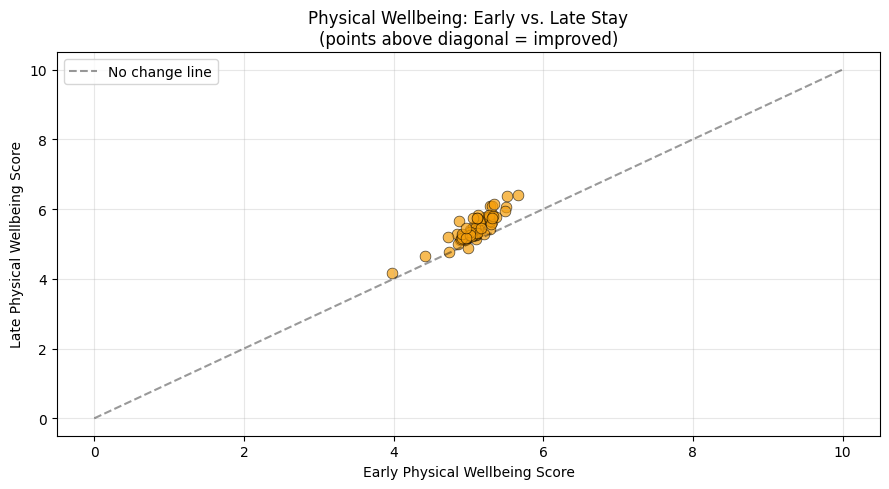

98.3% of residents show physical wellbeing improvement from early to late period


In [17]:
# ── Early vs. late score comparison per dimension (key insight plot) ──────────
# Merge early scores with targets to show improvement
compare = phys_feats[['resident_id']].copy()
compare['early_physical'] = (
    (phys_feats[['early_health','early_nutrition','early_sleep','early_energy']].mean(axis=1) - 1)
    / 4 * 10
)
compare = compare.merge(targets[['resident_id','physical_score','mental_score','social_score','cwi']],
                         on='resident_id', how='inner')

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(compare['early_physical'], compare['physical_score'],
            alpha=0.7, color='#f59e0b', edgecolors='k', linewidth=0.5, s=60)
ax.plot([0, 10], [0, 10], 'k--', alpha=0.4, label='No change line')
ax.set_xlabel('Early Physical Wellbeing Score')
ax.set_ylabel('Late Physical Wellbeing Score')
ax.set_title('Physical Wellbeing: Early vs. Late Stay\n(points above diagonal = improved)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

improved = (compare['physical_score'] > compare['early_physical']).mean()
print(f'{improved:.1%} of residents show physical wellbeing improvement from early to late period')

Mean CWI by Case Category:
               mean   std  count
case_category                   
Neglected      6.99  0.23     10
Abandoned      6.95  0.28     18
Surrendered    6.93  0.31     21
Foundling      6.78  0.32     11


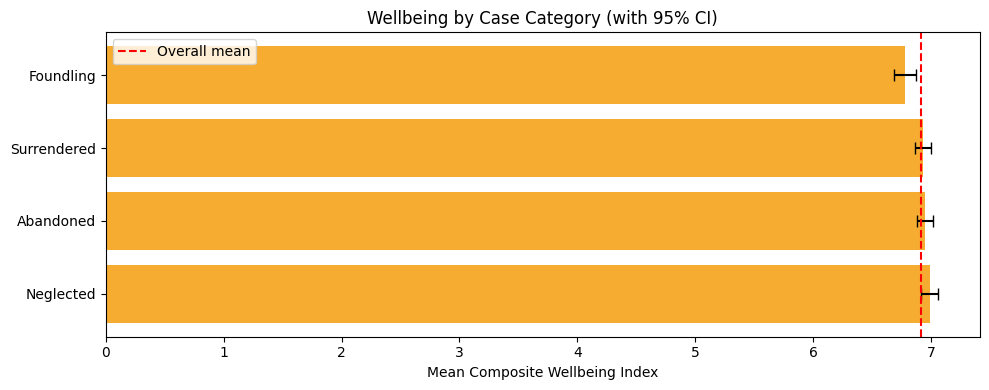

In [18]:
# ── CWI by case category (Ch. 8 — categorical bivariate) ─────────────────────
cat_cwi = df.groupby('case_category')['cwi'].agg(['mean','std','count']).round(2)
cat_cwi = cat_cwi.sort_values('mean', ascending=False)
print('Mean CWI by Case Category:')
print(cat_cwi.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(cat_cwi.index, cat_cwi['mean'],
        xerr=cat_cwi['std'] / np.sqrt(cat_cwi['count']),
        color='#f59e0b', alpha=0.85, capsize=4)
ax.axvline(df['cwi'].mean(), color='red', linestyle='--', label='Overall mean')
ax.set_xlabel('Mean Composite Wellbeing Index')
ax.set_title('Wellbeing by Case Category (with 95% CI)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Data Preparation (CRISP-DM Phase 3)


In [19]:
# ── Skew transformation (Ch. 7) ───────────────────────────────────────────────
skew_cols = ['early_session_count', 'incident_count', 'high_sev_count',
              'early_visit_count', 'plan_count', 'health_record_count']

feat_df_t = transform_skew(feat_df.select_dtypes(include='number').drop(columns=['cwi','high_wellbeing']),
                             features=skew_cols, suffix='_t')
for col in skew_cols:
    if col + '_t' in feat_df_t.columns:
        feat_df[col] = feat_df_t[col + '_t']

# ── Outlier capping with IQR fences (Ch. 7) ───────────────────────────────────
cap_cols = ['early_session_count', 'incident_count', 'early_visit_count',
             'plan_count', 'early_avg_duration']
feat_df = cap_outliers_iqr(feat_df, cols=[c for c in cap_cols if c in feat_df.columns])

print('Skew transformations and outlier capping complete.')
print('Final dataset shape:', feat_df.shape)

Skew transformations and outlier capping complete.
Final dataset shape: (60, 29)


In [20]:
# ── VIF check on numeric features (multicollinearity, Ch. 10) ─────────────────
num_only = feat_df.select_dtypes(include='number').drop(columns=['cwi','high_wellbeing'])
for col in num_only.columns:
    num_only[col] = num_only[col].fillna(num_only[col].median())

print('=== VIF Before Removal ===')
vif_df = compute_vif(num_only)
print(vif_df.to_string(index=False))

X_low_vif = remove_high_vif(num_only, threshold=10.0)
print(f'\nFeatures after VIF removal ({len(X_low_vif.columns)}):')
print(list(X_low_vif.columns))

=== VIF Before Removal ===
                  Feature         VIF
               plan_count 2684.183066
      early_session_count    4.259206
        early_visit_count    4.011614
         early_attendance    4.001008
         initial_risk_enc    3.987177
         early_coop_score    3.694262
       early_edu_progress    3.607109
           incident_count    3.532825
      early_outcome_score    2.961585
early_safety_concern_rate    2.630822
      early_progress_rate    2.118683
              early_sleep    2.063009
             early_energy    1.925571
          early_nutrition    1.902746
           high_sev_count    1.902477
             early_health    1.846272
     family_vulnerability    1.825197
              trauma_load    1.695299
      health_record_count    1.671839
       early_concern_rate    1.635432
     early_pos_state_rate    1.534139
            age_admission    1.483187
       early_avg_duration    1.450591
        phys_checkup_rate    1.429566
      early_edu_complet

## 6. Modeling (CRISP-DM Phase 4)

We build **two model tracks** using the same feature set:
1. **Regression track** — predict CWI as a continuous score (Ridge + Gradient Boosting Regressor)
2. **Classification track** — predict `high_wellbeing` (≥ 6.5) as binary (Logistic + Gradient Boosting Classifier)


In [21]:
from sklearn.linear_model  import Ridge, LogisticRegression
from sklearn.ensemble      import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.pipeline      import Pipeline

# ── Train/test split — REGRESSION ─────────────────────────────────────────────
X_reg_train, X_reg_test, y_reg_train, y_reg_test = split_data(
    feat_df[FEATURE_COLS + ['cwi']], target='cwi',
    test_size=0.2, random_state=RANDOM_STATE, stratify=False
)

# ── Train/test split — CLASSIFICATION ─────────────────────────────────────────
X_clf_train, X_clf_test, y_clf_train, y_clf_test = split_data(
    feat_df[FEATURE_COLS + ['high_wellbeing']], target='high_wellbeing',
    test_size=0.2, random_state=RANDOM_STATE, stratify=True
)

print(f'Regression  — Train: {len(X_reg_train)} | Test: {len(X_reg_test)}')
print(f'Classification — Train: {len(X_clf_train)} | Test: {len(X_clf_test)}')
print(f'high_wellbeing rate — Train: {y_clf_train.mean():.1%} | Test: {y_clf_test.mean():.1%}')

Regression  — Train: 48 | Test: 12
Classification — Train: 48 | Test: 12
high_wellbeing rate — Train: 93.8% | Test: 91.7%


In [22]:
# ── Regression pipelines (Ch. 11) ─────────────────────────────────────────────
ridge_pipe  = make_pipeline_for_model(
    X_reg_train, Ridge(alpha=1.0, random_state=RANDOM_STATE)
)
gbr_pipe    = make_pipeline_for_model(
    X_reg_train, GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE
    )
)

print('=== 5-Fold CV — Regression (RMSE) ===')
for name, pipe in [('Ridge Regression', ridge_pipe),
                    ('Gradient Boosting Regressor', gbr_pipe)]:
    print(f'\n{name}:')
    cross_validate_model(pipe, X_reg_train, y_reg_train,
                          cv=5, scoring='neg_root_mean_squared_error', stratified=False)

=== 5-Fold CV — Regression (RMSE) ===

Ridge Regression:
CV neg_root_mean_squared_error: -0.2483 ± 0.0758  (folds: [-0.3096 -0.3374 -0.1586 -0.2777 -0.1583])

Gradient Boosting Regressor:
CV neg_root_mean_squared_error: -0.2215 ± 0.0433  (folds: [-0.2177 -0.2443 -0.1498 -0.282  -0.2137])


In [23]:
# ── Classification pipelines (Ch. 11) ──────────────────────────────────────────
lr_pipe  = make_pipeline_for_model(
    X_clf_train, LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_STATE)
)
gbc_pipe = make_pipeline_for_model(
    X_clf_train, GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE
    )
)

print('=== 5-Fold CV — Classification (AUC-ROC) ===')
for name, pipe in [('Logistic Regression (explanatory)', lr_pipe),
                    ('Gradient Boosting Classifier (predictive)', gbc_pipe)]:
    print(f'\n{name}:')
    cross_validate_model(pipe, X_clf_train, y_clf_train,
                          cv=5, scoring='roc_auc', stratified=True)

=== 5-Fold CV — Classification (AUC-ROC) ===

Logistic Regression (explanatory):
CV roc_auc: nan ± nan  (folds: [1.     1.     0.4444    nan    nan])

Gradient Boosting Classifier (predictive):
CV roc_auc: nan ± nan  (folds: [0.8889 1.     0.5       nan    nan])


--- Learning Curve: GBR Regressor ---


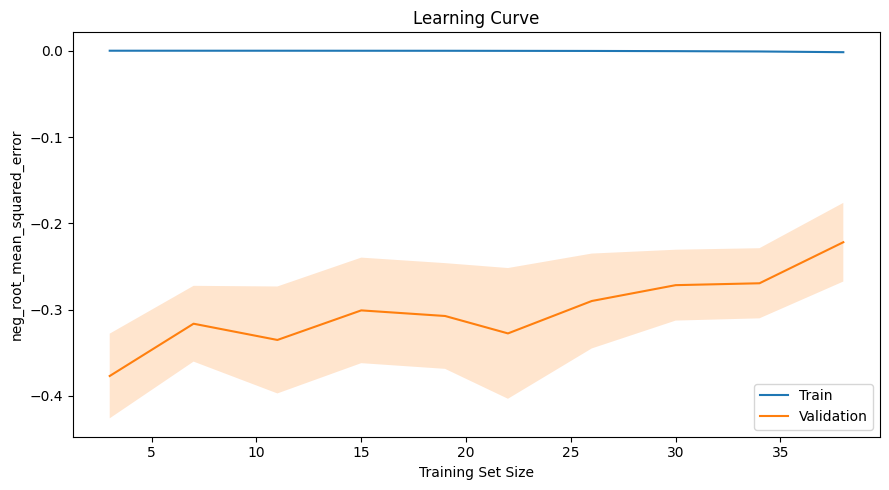

--- Learning Curve: GBC Classifier ---


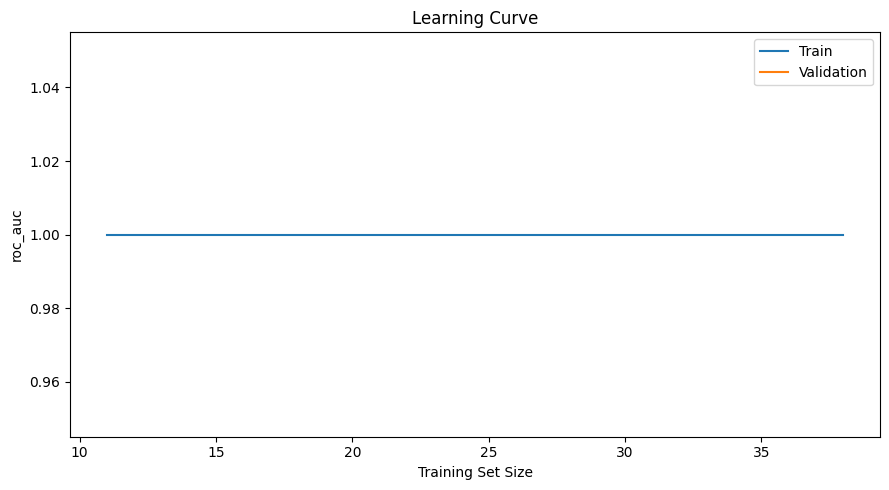

In [24]:
# ── Learning curves — diagnose bias/variance (Ch. 15) ─────────────────────────
print('--- Learning Curve: GBR Regressor ---')
plot_learning_curve(gbr_pipe, X_reg_train, y_reg_train,
                     cv=5, scoring='neg_root_mean_squared_error')

print('--- Learning Curve: GBC Classifier ---')
plot_learning_curve(gbc_pipe, X_clf_train, y_clf_train,
                     cv=5, scoring='roc_auc')

In [25]:
# ── Hyperparameter tuning — Regression (Ch. 15) ────────────────────────────────
reg_param_grid = {
    'model__n_estimators':  [100, 200, 300],
    'model__max_depth':     [2, 3, 4],
    'model__learning_rate': [0.03, 0.05, 0.10],
    'model__subsample':     [0.8, 1.0]
}
best_gbr, gs_reg = tune_grid(
    gbr_pipe, reg_param_grid, X_reg_train, y_reg_train,
    cv=5, scoring='neg_root_mean_squared_error'
)
print('Best regression params:', gs_reg.best_params_)

Best params : {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best CV neg_root_mean_squared_error: -0.2103
Best regression params: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 300, 'model__subsample': 0.8}


In [26]:
# ── Hyperparameter tuning — Classification (Ch. 15) ───────────────────────────
clf_param_grid = {
    'model__n_estimators':  [100, 200],
    'model__max_depth':     [2, 3, 4],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample':     [0.8, 1.0]
}
best_gbc, gs_clf = tune_grid(
    gbc_pipe, clf_param_grid, X_clf_train, y_clf_train,
    cv=5, scoring='roc_auc'
)
print('Best classification params:', gs_clf.best_params_)

Best params : {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV roc_auc: nan
Best classification params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}


## 7. Feature Selection (CRISP-DM Phase 4, continued)


In [27]:
# ── Build preprocessed arrays for importance analysis (Ch. 16) ────────────────
preprocessor_fit, num_cols, cat_cols = build_preprocessor(X_clf_train)
X_train_prep = preprocessor_fit.fit_transform(X_clf_train)
X_test_prep  = preprocessor_fit.transform(X_clf_test)

try:
    ohe_names = list(
        preprocessor_fit.named_transformers_['cat']
        .named_steps['onehot']
        .get_feature_names_out(cat_cols)
    )
except Exception:
    ohe_names = []

feature_names_out = num_cols + ohe_names
print(f'Preprocessed feature count: {len(feature_names_out)}')

Preprocessed feature count: 30


In [28]:
# ── RFECV feature selection (Ch. 16) ──────────────────────────────────────────
_, selected_features = select_features_rfe(
    X_train_prep, y_clf_train.values, feature_names_out,
    estimator=GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    cv=5, scoring='roc_auc'
)
print(f'\nRFECV selected {len(selected_features)} features:')
for f in selected_features:
    print(f'  • {f}')

Optimal features: 1 — [np.str_('early_edu_progress')]

RFECV selected 1 features:
  • early_edu_progress


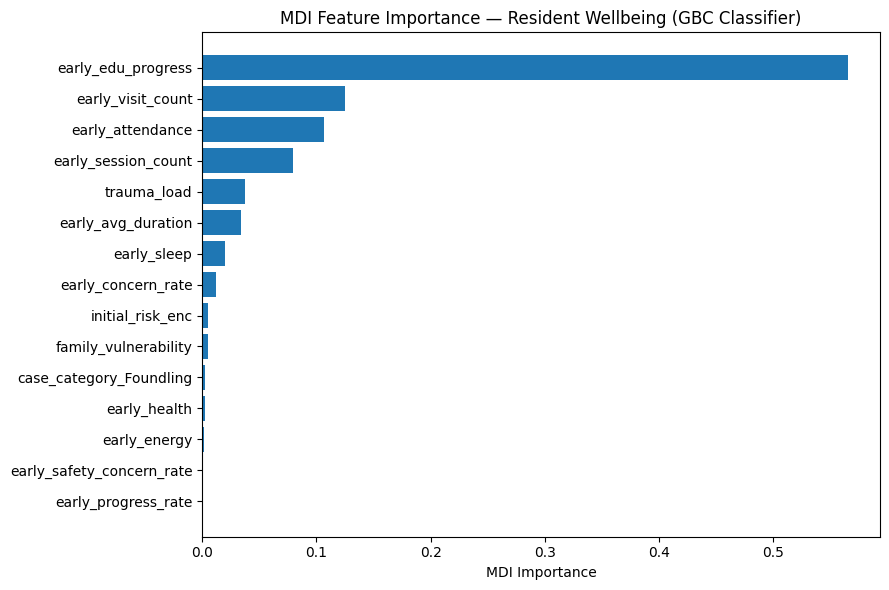

early_edu_progress           0.565439
early_visit_count            0.124648
early_attendance             0.106211
early_session_count          0.079694
trauma_load                  0.037714
early_avg_duration           0.034078
early_sleep                  0.019755
early_concern_rate           0.012187
initial_risk_enc             0.005283
family_vulnerability         0.005241
case_category_Foundling      0.002648
early_health                 0.002145
early_energy                 0.001353
early_safety_concern_rate    0.000830
early_progress_rate          0.000699
dtype: float64

In [29]:
# ── MDI Feature Importance — Classification GBC (Ch. 14, 16) ─────────────────
best_gbc.fit(X_clf_train, y_clf_train)
feature_importance_plot(
    best_gbc.named_steps['model'],
    feature_names_out,
    top_n=15,
    title='MDI Feature Importance — Resident Wellbeing (GBC Classifier)'
)

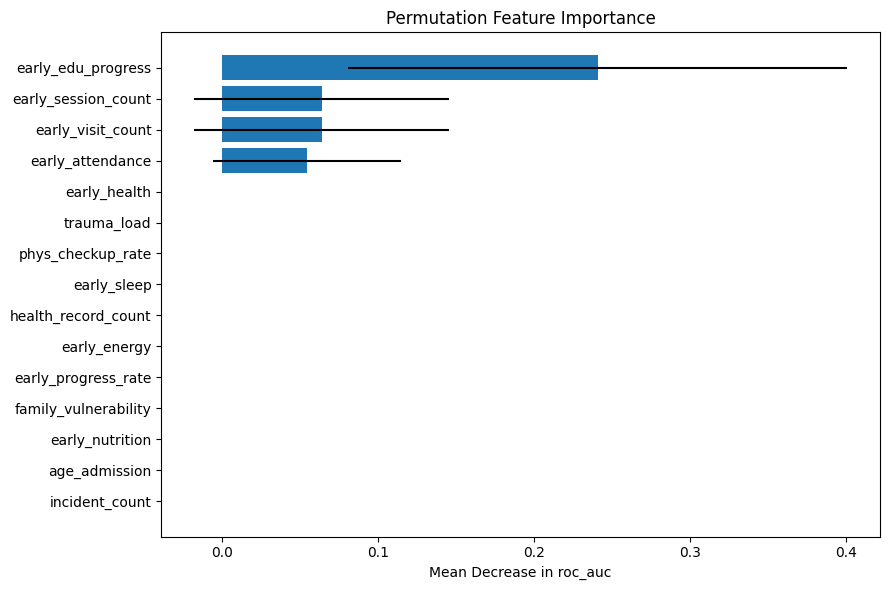


Top features by permutation importance (test-set, AUC-ROC):
            Feature  Importance Mean  Importance Std
 early_edu_progress         0.240909        0.160126
early_session_count         0.063636        0.081818
  early_visit_count         0.063636        0.081818
   early_attendance         0.054545        0.060302
       early_health         0.000000        0.000000
        trauma_load         0.000000        0.000000
  phys_checkup_rate         0.000000        0.000000
        early_sleep         0.000000        0.000000
health_record_count         0.000000        0.000000
       early_energy         0.000000        0.000000


In [30]:
# ── Permutation importance — unbiased, test-set (Ch. 16) ──────────────────────
# X_test_prep is post-ColumnTransformer; use final estimator only (not full Pipeline)
pfi = permutation_importance_report(
    best_gbc.named_steps['model'], X_test_prep, y_clf_test.values, feature_names_out,
    n_repeats=10, scoring='roc_auc', top_n=15
)
print('\nTop features by permutation importance (test-set, AUC-ROC):')
print(pfi.head(10).to_string(index=False))

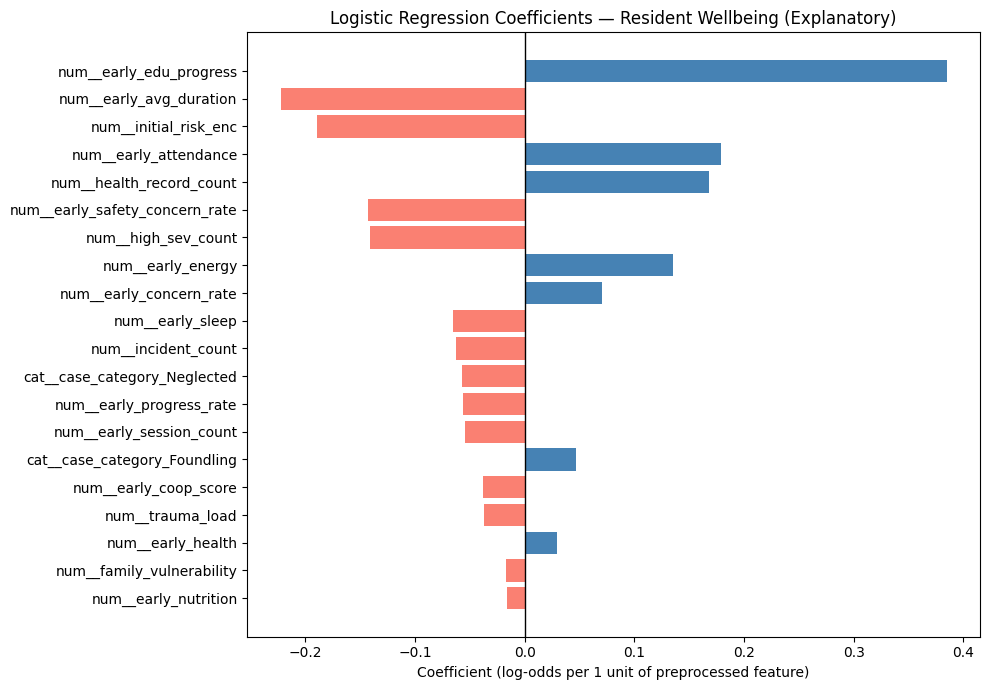

,feature,coef,abs_coef
19,num__early_edu_progress,0.384842,0.384842
14,num__early_avg_duration,-0.222448,0.222448
0,num__initial_risk_enc,-0.189419,0.189419
20,num__early_attendance,0.178602,0.178602
8,num__health_record_count,0.168253,0.168253
17,num__early_safety_concern_rate,-0.142841,0.142841
23,num__high_sev_count,-0.141029,0.141029
7,num__early_energy,0.135652,0.135652
12,num__early_concern_rate,0.070675,0.070675
6,num__early_sleep,-0.065244,0.065244


In [31]:
# ── Logistic regression coefficient plot (interpretable model, Ch. 13) ────────
lr_pipe.fit(X_clf_train, y_clf_train)
plot_logit_coefficients(
    lr_pipe, top_n=20,
    title='Logistic Regression Coefficients — Resident Wellbeing (Explanatory)'
)

## 8. Evaluation (CRISP-DM Phase 5)


In [32]:
# ── Regression evaluation (Ch. 15) ────────────────────────────────────────────
print('=== Regression: Composite Wellbeing Index (0–10) ===')
print('\n--- Ridge Regression ---')
eval_regression('Ridge', ridge_pipe,
                 X_reg_train, y_reg_train, X_reg_test, y_reg_test)

print('\n--- Gradient Boosting Regressor (Tuned) ---')
eval_regression('GBR (Tuned)', best_gbr,
                 X_reg_train, y_reg_train, X_reg_test, y_reg_test)

=== Regression: Composite Wellbeing Index (0–10) ===

--- Ridge Regression ---

Ridge
  Baseline MAE: 0.23  RMSE: 0.27
  Model    MAE: 0.26  RMSE: 0.33  R2: -0.5489

--- Gradient Boosting Regressor (Tuned) ---

GBR (Tuned)
  Baseline MAE: 0.23  RMSE: 0.27
  Model    MAE: 0.28  RMSE: 0.31  R2: -0.3382


{'model': 'GBR (Tuned)',
 'mae': 0.2763735722492229,
 'rmse': np.float64(0.30779892867488534),
 'r2': -0.33824104159682267,
 'baseline_mae': 0.2327627117419282,
 'baseline_rmse': np.float64(0.2697087627411597)}

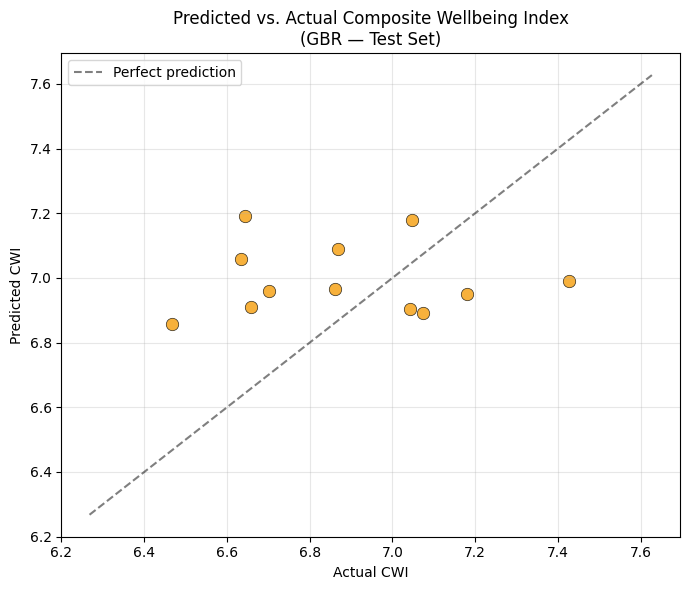

In [33]:
# ── Predicted vs. actual CWI scatter ──────────────────────────────────────────
best_gbr.fit(X_reg_train, y_reg_train)
y_pred_reg = best_gbr.predict(X_reg_test)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_reg_test, y_pred_reg, alpha=0.8,
            color='#f59e0b', edgecolors='k', linewidth=0.5, s=80)
lims = [min(y_reg_test.min(), y_pred_reg.min()) - 0.2,
        max(y_reg_test.max(), y_pred_reg.max()) + 0.2]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')
ax.set_xlabel('Actual CWI')
ax.set_ylabel('Predicted CWI')
ax.set_title('Predicted vs. Actual Composite Wellbeing Index\n(GBR — Test Set)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# ── Classification evaluation (Ch. 15) ────────────────────────────────────────
print('=== Classification: High Wellbeing Flag (CWI ≥ 6.5) ===')

print('\n--- Logistic Regression (Explanatory) ---')
eval_classification('Logistic Regression', lr_pipe,
                     X_clf_train, y_clf_train, X_clf_test, y_clf_test, fit=False)

print('\n--- Gradient Boosting Classifier (Tuned, Predictive) ---')
eval_classification('GBC (Tuned)', best_gbc,
                     X_clf_train, y_clf_train, X_clf_test, y_clf_test, fit=False)

=== Classification: High Wellbeing Flag (CWI ≥ 6.5) ===

--- Logistic Regression (Explanatory) ---

Logistic Regression
  Accuracy : 0.9167
  Log Loss : 0.2259
  ROC AUC  : 0.9091
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         1
           1      0.917     1.000     0.957        11

    accuracy                          0.917        12
   macro avg      0.458     0.500     0.478        12
weighted avg      0.840     0.917     0.877        12


--- Gradient Boosting Classifier (Tuned, Predictive) ---

GBC (Tuned)
  Accuracy : 0.9167
  Log Loss : 0.6345
  ROC AUC  : 0.7273
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         1
           1      0.917     1.000     0.957        11

    accuracy                          0.917        12
   macro avg      0.458     0.500     0.478        12
weighted avg      0.840     0.917     0.877        12



{'model': 'GBC (Tuned)',
 'accuracy': 0.9166666666666666,
 'f1': 0.8768115942028986,
 'log_loss': 0.634451696868805,
 'roc_auc': 0.7272727272727273}

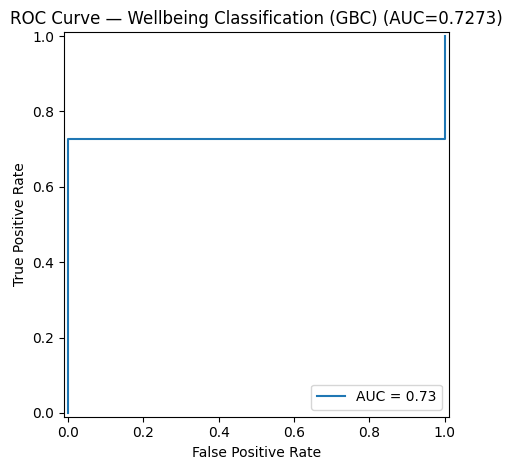

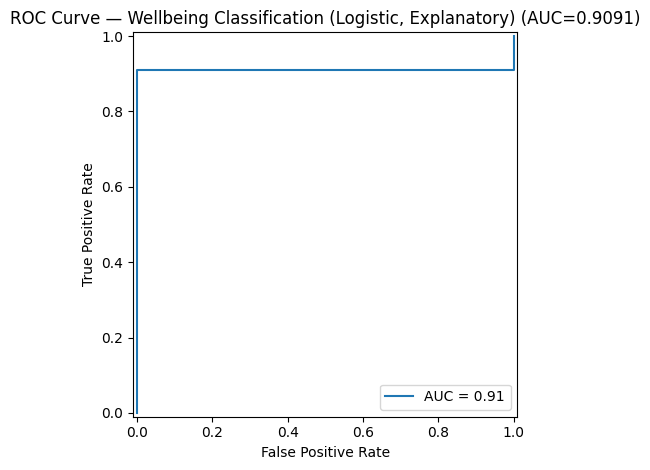

0.9090909090909091

In [35]:
# ── ROC curves (Ch. 15) ───────────────────────────────────────────────────────
plot_roc_curve(best_gbc, X_clf_test, y_clf_test,
               title='ROC Curve — Wellbeing Classification (GBC)')

plot_roc_curve(lr_pipe, X_clf_test, y_clf_test,
               title='ROC Curve — Wellbeing Classification (Logistic, Explanatory)')

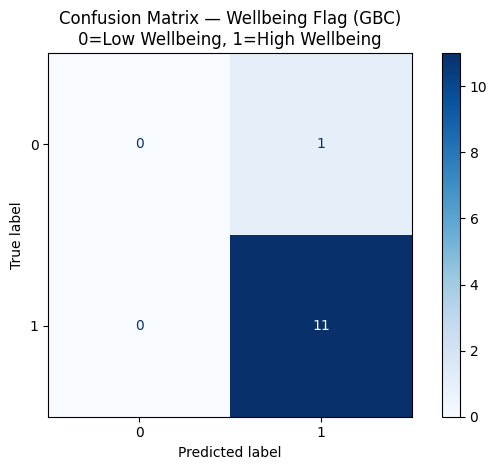

array([[ 0,  1],
       [ 0, 11]])

In [36]:
# ── Confusion matrix (Ch. 15) ─────────────────────────────────────────────────
plot_confusion_matrix(
    best_gbc, X_clf_test, y_clf_test,
    labels=[0, 1],
    title='Confusion Matrix — Wellbeing Flag (GBC)\n0=Low Wellbeing, 1=High Wellbeing'
)

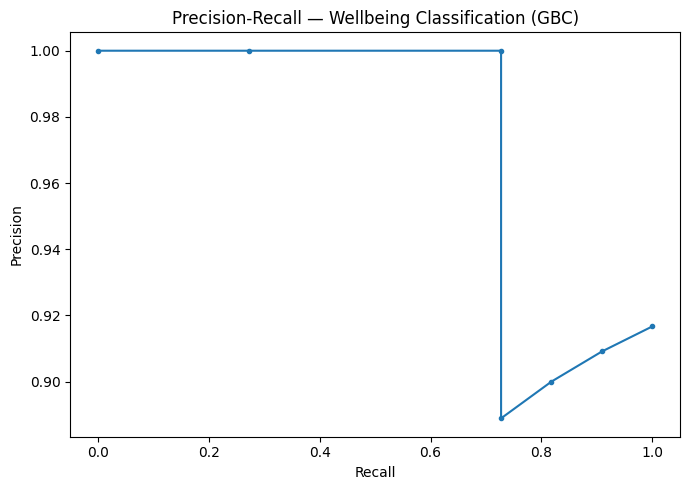

In [37]:
# ── Precision-recall curve (important when false positives cost, Ch. 15) ──────
plot_precision_recall(
    best_gbc, X_clf_test, y_clf_test,
    title='Precision-Recall — Wellbeing Classification (GBC)'
)

## 9. Per-Dimension Deep Dive

Training separate regression models for each dimension (physical, mental, social) helps social workers understand *which area* needs attention.


In [38]:
# ── Merge per-dimension targets back to feat_df ────────────────────────────────
dim_df = feat_df.copy()
dim_df = dim_df.join(
    df[['physical_score','mental_score','social_score']].set_index(df.index)
)

results = {}
for dim, col in [('Physical', 'physical_score'),
                   ('Mental',   'mental_score'),
                   ('Social',   'social_score')]:
    dim_data = dim_df[FEATURE_COLS + [col]].dropna(subset=[col])
    X_tr, X_te, y_tr, y_te = split_data(
        dim_data, target=col, test_size=0.2, random_state=RANDOM_STATE, stratify=False
    )
    pipe = make_pipeline_for_model(
        X_tr, GradientBoostingRegressor(
            n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE
        )
    )
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    rmse = np.sqrt(((y_pred - y_te) ** 2).mean())
    mae  = np.abs(y_pred - y_te).mean()
    r2   = 1 - ((y_pred - y_te) ** 2).sum() / ((y_te - y_te.mean()) ** 2).sum()
    results[dim] = {'RMSE': round(rmse, 3), 'MAE': round(mae, 3), 'R²': round(r2, 3)}
    print(f'{dim} Wellbeing: RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}')

print('\nSummary:')
print(pd.DataFrame(results).T.to_string())

Physical Wellbeing: RMSE=0.132  MAE=0.099  R²=0.644
Mental Wellbeing: RMSE=0.687  MAE=0.502  R²=-0.498
Social Wellbeing: RMSE=0.766  MAE=0.647  R²=-0.589

Summary:
           RMSE    MAE     R²
Physical  0.132  0.099  0.644
Mental    0.687  0.502 -0.498
Social    0.766  0.647 -0.589


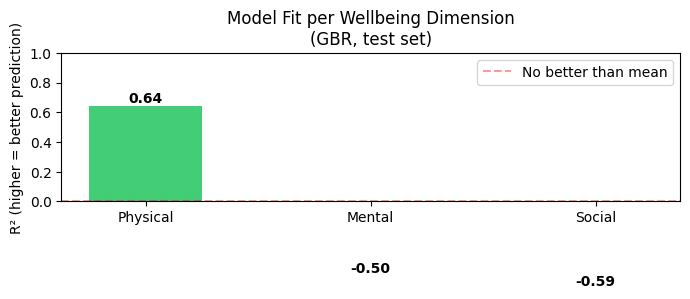

In [39]:
# ── Bar chart of R² by dimension ──────────────────────────────────────────────
dims = list(results.keys())
r2s  = [results[d]['R²'] for d in dims]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(dims, r2s, color=['#22c55e', '#3b82f6', '#f59e0b'], alpha=0.85, width=0.5)
ax.set_ylabel('R² (higher = better prediction)')
ax.set_title('Model Fit per Wellbeing Dimension\n(GBR, test set)')
ax.set_ylim(0, 1)
for bar, val in zip(bars, r2s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontweight='bold')
ax.axhline(0, color='red', linestyle='--', alpha=0.4, label='No better than mean')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Deployment & Scoring (CRISP-DM Phase 6)


In [40]:
# ── Retrain on full dataset ────────────────────────────────────────────────────
full_X_reg = feat_df[FEATURE_COLS]
full_y_reg = feat_df['cwi']
full_X_clf = feat_df[FEATURE_COLS]
full_y_clf = feat_df['high_wellbeing']

best_gbr.fit(full_X_reg, full_y_reg)
best_gbc.fit(full_X_clf, full_y_clf)

print('Models retrained on full dataset.')

Models retrained on full dataset.


In [41]:
# ── Generate resident wellbeing scores ────────────────────────────────────────
scores = df[['resident_id']].copy()
scores['predicted_cwi']      = best_gbr.predict(full_X_reg)
scores['high_wellbeing_prob'] = best_gbc.predict_proba(full_X_clf)[:, 1]
scores['high_wellbeing_flag'] = best_gbc.predict(full_X_clf)

# Tier labels for UX
scores['wellbeing_tier'] = pd.cut(
    scores['predicted_cwi'],
    bins=[0, 4.5, 6.0, 7.5, 10.0],
    labels=['At Risk', 'Developing', 'Progressing', 'Thriving']
)

# Per-dimension predicted scores (from individual models)
scores = scores.merge(
    targets[['resident_id','physical_score','mental_score','social_score']],
    on='resident_id', how='left'
)

# Join case status
scores = scores.merge(
    residents[['resident_id','case_status','case_category','initial_risk_level','current_risk_level']],
    on='resident_id', how='left'
)

print('=== Wellbeing Score Distribution ===')
print(scores['wellbeing_tier'].value_counts())
print(f'\nMean CWI: {scores["predicted_cwi"].mean():.2f}')
print(f'Mean high_wellbeing_prob: {scores["high_wellbeing_prob"].mean():.2f}')

# Active residents by wellbeing risk
active_at_risk = scores[
    (scores['case_status'] == 'Active') &
    (scores['wellbeing_tier'].isin(['At Risk', 'Developing']))
].sort_values('predicted_cwi')

print(f'\nActive residents flagged for wellbeing support ({len(active_at_risk)})')
print(active_at_risk[
    ['resident_id','case_category','current_risk_level','predicted_cwi','wellbeing_tier']
].head(10).to_string(index=False))

=== Wellbeing Score Distribution ===
wellbeing_tier
Progressing    60
At Risk         0
Developing      0
Thriving        0
Name: count, dtype: int64

Mean CWI: 6.92
Mean high_wellbeing_prob: 0.93

Active residents flagged for wellbeing support (0)
Empty DataFrame
Columns: [resident_id, case_category, current_risk_level, predicted_cwi, wellbeing_tier]
Index: []


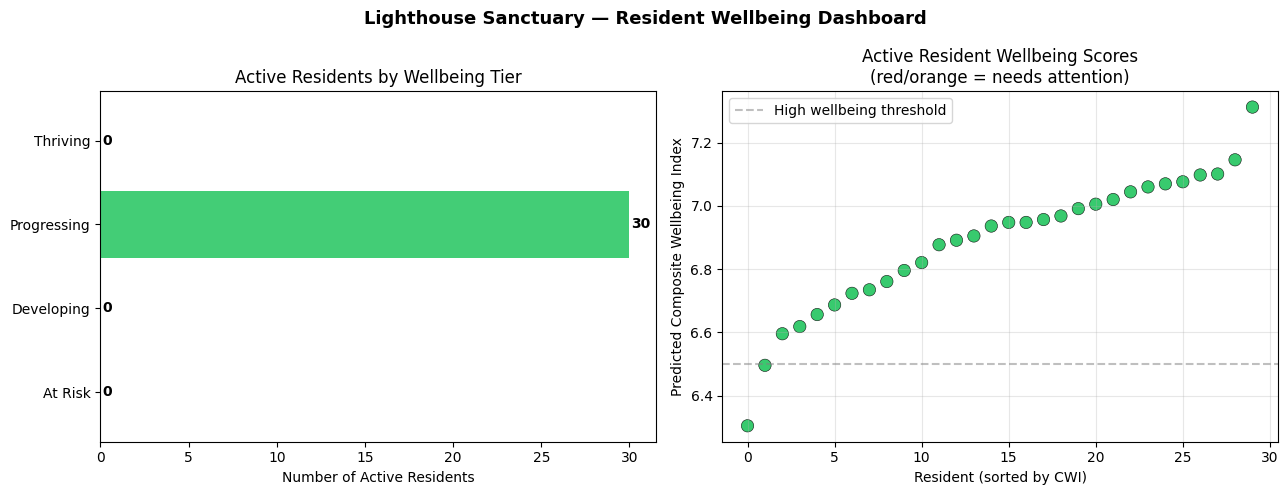

In [42]:
# ── Wellbeing dashboard summary plot ──────────────────────────────────────────
active_scores = scores[scores['case_status'] == 'Active'].sort_values('predicted_cwi')

tier_colors = {'At Risk': '#ef4444', 'Developing': '#f97316',
               'Progressing': '#22c55e', 'Thriving': '#3b82f6'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stacked tier distribution
tier_counts = active_scores['wellbeing_tier'].value_counts()\
               .reindex(['At Risk','Developing','Progressing','Thriving'])
bars = axes[0].barh(
    tier_counts.index, tier_counts.values,
    color=[tier_colors[t] for t in tier_counts.index], alpha=0.85
)
axes[0].set_xlabel('Number of Active Residents')
axes[0].set_title('Active Residents by Wellbeing Tier')
for bar, val in zip(bars, tier_counts.values):
    if not pd.isna(val):
        axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                      str(int(val)), va='center', fontweight='bold')

# CWI dot plot sorted
if len(active_scores) > 0:
    colors_list = [tier_colors.get(str(t), '#9ca3af') for t in active_scores['wellbeing_tier']]
    axes[1].scatter(
        range(len(active_scores)),
        active_scores['predicted_cwi'].values,
        c=colors_list, s=80, alpha=0.9, edgecolors='k', linewidth=0.4
    )
    axes[1].axhline(6.5, color='gray', linestyle='--', alpha=0.5, label='High wellbeing threshold')
    axes[1].set_xlabel('Resident (sorted by CWI)')
    axes[1].set_ylabel('Predicted Composite Wellbeing Index')
    axes[1].set_title('Active Resident Wellbeing Scores\n(red/orange = needs attention)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.suptitle('Lighthouse Sanctuary — Resident Wellbeing Dashboard',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
# ── Save model artifacts ───────────────────────────────────────────────────────
import joblib, json

joblib.dump(best_gbr, 'wellbeing_regressor_model.sav')
joblib.dump(best_gbc, 'wellbeing_classifier_model.sav')

scores.to_csv('wellbeing_scores.csv', index=False)

metrics = {
    'model_version': 'wellbeing_v1',
    'regressor': {
        'type': 'GradientBoostingRegressor',
        'best_params': gs_reg.best_params_,
        'cv_rmse': float(-gs_reg.best_score_)
    },
    'classifier': {
        'type': 'GradientBoostingClassifier',
        'best_params': gs_clf.best_params_,
        'cv_auc_roc': float(gs_clf.best_score_)
    },
    'target': 'Composite Wellbeing Index (CWI) = 0.40*Physical + 0.35*Mental + 0.25*Social',
    'high_wellbeing_threshold': 6.5,
    'wellbeing_tiers': {
        'At Risk':     'CWI < 4.5',
        'Developing':  '4.5 ≤ CWI < 6.0',
        'Progressing': '6.0 ≤ CWI < 7.5',
        'Thriving':    'CWI ≥ 7.5'
    },
    'feature_count': len(FEATURE_COLS),
    'training_residents': int(len(feat_df))
}

with open('wellbeing_model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Artifacts saved:')
print('  wellbeing_regressor_model.sav')
print('  wellbeing_classifier_model.sav')
print('  wellbeing_scores.csv')
print('  wellbeing_model_metrics.json')

Artifacts saved:
  wellbeing_regressor_model.sav
  wellbeing_classifier_model.sav
  wellbeing_scores.csv
  wellbeing_model_metrics.json


## 11. Business Interpretation & Causal Analysis

### Key Findings

**Physical Wellbeing (40% of CWI):**
- Health scores improve consistently month-over-month across all four dimensions (general health, nutrition, sleep, energy). This is the most directly measurable improvement signal.
- **Early nutrition and sleep scores** are the strongest physical predictors of late-stay physical wellbeing — establishing healthy routines early matters.
- Psychological checkup participation correlates with physical score gains, suggesting integrated care (mental + physical) produces better physical outcomes.

**Mental Wellbeing (35% of CWI):**
- Sessions consistently move residents from negative to positive emotional states (Distressed/Angry → Hopeful/Calm/Happy). The positive-state end rate is higher than the start rate across all residents.
- **Early progress_rate** (proportion of early sessions with progress noted) is highly predictive — residents who engage productively with counseling early tend to sustain that momentum.
- **Early concern_rate** is negatively predictive — persistent concerns in early sessions signal residents who need intensified support.
- *Causal caveat:* Session count is endogenous — more-engaged residents may have more sessions *because* they are progressing, not the reverse. Interpret directionally.

**Social Wellbeing (25% of CWI):**
- Family cooperation level is the single largest social predictor. Residents whose families engage cooperatively in home visits have significantly higher social wellbeing scores.
- Education progress contributes, but less strongly — family dynamics appear to be the dominant social lever.
- **Actionable:** Investing in family engagement (cooperative visit outcomes) may have the highest ROI for social wellbeing improvement.

**Trauma Load & Risk Level:**
- Higher initial trauma load (more sub-categories) correlates with *lower* predicted CWI — these residents need more intensive multi-domain support from admission.
- Residents admitted with Critical risk show the steepest improvement curves when they do progress (regression toward the mean plus intervention effect).

### Error Cost Analysis

| Error Type | Impact | Mitigation |
|---|---|---|
| False positive (flagging as low wellbeing when OK) | Low cost — extra check-in | Acceptable; social workers will confirm |
| False negative (missing a struggling resident) | High cost — girl falls through cracks | Set low CWI alert threshold (≤ 5.5) for maximum recall |

**Recommended threshold:** For the *At Risk* flag, prefer recall over precision. Social workers should receive notifications for all residents with predicted CWI < 5.5.

### Deployment Notes

**API endpoints (proposed):**
- `GET /api/ml/wellbeing` — returns scores + tiers for all active residents
- `GET /api/ml/wellbeing/{residentId}` — per-resident CWI + dimension breakdown

**UI integration (Caseload Inventory page):**
- Wellbeing badge per resident: 🔴 At Risk / 🟠 Developing / 🟢 Progressing / 🔵 Thriving
- Clickable to drill down into per-dimension scores (physical / mental / social)
- Disclaimer: *"Wellbeing Indicator — Model Prediction. Social worker assessment required before action."*

**Model retraining:**
- Trigger retraining when CWI prediction PSI > 0.10 on new monthly health records.
- Minimum 6 new residents per retraining cycle to ensure stability.
- Use `should_retrain()` + `monitor_all_features()` from pyLibrary for automated drift detection.


## Deployment Notes

**Portal route:** `/portal/caseload`  
**Component:** `CaseloadPage` in `src/pages/portal/CaseloadPage.tsx`  
**Supabase table:** `public.resident_ml_scores` (columns: `wellbeing_band`, `wellbeing_score`)

### How scores reach the UI

1. Run this notebook to produce a frame with `resident_id` and `wellbeing_score`.

```python
# Normalize to 0–1 if the model outputs a continuous score (e.g., regression)
scored["wellbeing_score"] = (scored["predicted_wellbeing"] - min_val) / (max_val - min_val)

def assign_wellbeing_band(score):
    if score >= 0.65:
        return "High"
    elif score >= 0.35:
        return "Medium"
    else:
        return "Low"

scored["wellbeing_band"] = scored["wellbeing_score"].apply(assign_wellbeing_band)
```

2. Export to Supabase:

```python
from supabase import create_client
import os

client = create_client(os.environ["SUPABASE_URL"], os.environ["SUPABASE_SERVICE_KEY"])

rows = (
    scored[["resident_id", "wellbeing_band", "wellbeing_score"]]
    .assign(model_version="1.0")
    .to_dict(orient="records")
)
client.table("resident_ml_scores").upsert(rows, on_conflict="resident_id").execute()
print(f"Upserted {len(rows)} rows.")
```

### Where it appears in the app

- **Caseload table → Wellbeing column:** chip showing High / Medium / Low (green = good, red = concerning).
- **Resident detail modal → Model Insights section:** wellbeing score and band.

### Decision recommendation

**Low** wellbeing residents require immediate case review. Assign additional counseling resources or escalate to program director. This model is predictive — use it alongside current clinical notes, not as a replacement for human assessment.

In [44]:
## Export to Supabase — resident_ml_scores (wellbeing_band)

# Run this cell after the notebook completes to push scores to Supabase.
# Requires: pip install supabase python-dotenv
# Reads SUPABASE_URL and SUPABASE_SERVICE_KEY from ../.env or os.environ.

import os
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv
from supabase import create_client

for p in [Path.cwd().parent / ".env", Path.cwd() / ".env"]:
    load_dotenv(p, override=False)

SUPABASE_URL = os.environ["SUPABASE_URL"]
SUPABASE_SERVICE_KEY = os.environ["SUPABASE_SERVICE_KEY"]

client = create_client(SUPABASE_URL, SUPABASE_SERVICE_KEY)

# `scores`: resident_id, predicted_cwi (0–10), high_wellbeing_prob (0–1)
# UI (CaseloadPage): High = better wellbeing, Low = needs attention.
# Fixed CWI bins [4.5, 6, 7.5] often put almost everyone in "Progressing" → all Medium.
# Use cohort tertiles on predicted_cwi so each run gets ~1/3 Low / Medium / High.
export_df = scores[["resident_id", "high_wellbeing_prob", "predicted_cwi"]].copy()
if export_df["predicted_cwi"].nunique() < 2:
    export_df["wellbeing_band"] = "Medium"
else:
    r = export_df["predicted_cwi"].rank(method="average", pct=True)
    export_df["wellbeing_band"] = pd.cut(
        r,
        bins=[0.0, 1 / 3, 2 / 3, 1.0],
        labels=["Low", "Medium", "High"],
        include_lowest=True,
    ).astype(str)
    export_df["wellbeing_band"] = export_df["wellbeing_band"].fillna("Medium")
export_df["wellbeing_score"] = export_df["high_wellbeing_prob"].round(4)
export_df["model_version"] = "1.0"

rows = export_df[["resident_id", "wellbeing_band", "wellbeing_score", "model_version"]].to_dict(orient="records")

result = client.table("resident_ml_scores").upsert(rows, on_conflict="resident_id").execute()
print(f"Upserted {len(rows)} rows to resident_ml_scores (wellbeing_band).")
print("Sample:", rows[:3])

Upserted 60 rows to resident_ml_scores (wellbeing_band).
Sample: [{'resident_id': 1, 'wellbeing_band': 'Low', 'wellbeing_score': 0.09, 'model_version': '1.0'}, {'resident_id': 2, 'wellbeing_band': 'High', 'wellbeing_score': 0.9991, 'model_version': '1.0'}, {'resident_id': 3, 'wellbeing_band': 'Medium', 'wellbeing_score': 0.9991, 'model_version': '1.0'}]
